In [ ]:
import sys, os, pickle, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as _stats


sys.path.insert(0, '/Users/yotameviatar/startle-1')
warnings.filterwarnings('ignore')

from Airflow import airflow_config as config
from Airflow import airflow_amp_processor as processor
from IPython import get_ipython

# ── Force the inline backend AFTER the imports above ──────────────────────────
# Importing the processor pulls in trial_epochs -> emg_raw_potentiation, which
# runs matplotlib.use("Agg") at import time (Agg renders to files, NOT to the
# notebook). If %matplotlib inline ran before that import, Agg silently wins and
# every plt.show() below draws nothing. Re-asserting inline here, last, guarantees
# figures display. Must be the magic, run after all imports — do not move it up.

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110})
print('Setup complete — backend:', matplotlib.get_backend())

In [28]:
# ── What to show ──────────────────────────────────────────────────────────────
SUBJECT   = 'EV15'    # subject ID
SESSION   = None      # 'eve', 'mor', or None for both

# ── Signal display ────────────────────────────────────────────────────────────
SHOW_NK2  = True      # overlay NK2-cleaned signal on raw (blue/red colour)
RAW_ONLY  = False     # True = grey raw only, no NK2 overlay

# ── Layout ───────────────────────────────────────────────────────────────────
NCOLS     = 6
SAVE_FIGS = False     # also write PNGs to OUTPUT_DIR/raw_show/<subject>/

In [29]:
# ── Load cache — handles old format (trials) and new format (sessions) ────────
cache_path = os.path.join(config.OUTPUT_DIR, '_cache', 'airflow_cache.pkl')
with open(cache_path, 'rb') as f:
    _cache = pickle.load(f)

if 'sessions' in _cache:
    print('Cache format: new (sessions)')
    trials_data, traces = processor.apply_analysis_params(_cache['sessions'], config)
else:
    print('Cache format: old (trials) — re-scoring from cached epochs')
    raw_trials = _cache['trials']
    traces     = _cache.get('traces', {})
    trials_data = {}
    for subj, sess_dict in sorted(raw_trials.items()):
        trials_data[subj] = {}
        for sess_key, trial_list in sess_dict.items():
            trials = [dict(t) for t in trial_list]
            for t in trials:
                t['score'] = None
                t['rejected'] = None; t['rejection_reason'] = ''
                t['epoch_anal'] = None; t['times_anal'] = None
            processor._run_demo_analysis(trials, config)
            trials_data[subj][sess_key] = trials

if SUBJECT not in trials_data:
    raise ValueError(f"Subject '{SUBJECT}' not found. Available: {sorted(trials_data.keys())}")

show_nk2  = SHOW_NK2 and not RAW_ONLY
sess_keys = ([SESSION] if SESSION else
             sorted(k for k in trials_data[SUBJECT] if trials_data[SUBJECT][k]))

for sk in sess_keys:
    trials = trials_data[SUBJECT].get(sk, [])
    n_rej  = sum(1 for t in trials if t.get('rejected'))
    print(f"{SUBJECT} {config.SESSION_MAP.get(sk,{}).get('label', sk)}: "
          f"{len(trials)} trials, {n_rej} rejected")

Cache format: new (sessions)
  [shape-centroid] 0/40 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.120e+00  1 trial(s) excluded from matrix (epoch shorter than shape window)
  [shape-centroid] 0/38 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.322e+00  1 trial(s) excluded from matrix (epoch shorter than shape window)
  [shape-centroid] 0/37 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.314e+00  1 trial(s) excluded from matrix (epoch shorter than shape window)
  [shape-centroid] 0/38 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.248e+00  1 trial(s) excluded from matrix (epoch shorter than shape window)
  [shape-centroid] 0/39 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.154e+00
  [shape-centroid] 0/39 trials flagged as atypical_shape  window=[-5.0, 10.0s]  threshold=3.0SD  MSD cutoff=1.426

## Rejection Reason Key

| # | Code | Meaning |
|---|---|---|
| **1** | `no_cycles_found` | **No breaths found:** Could not detect any valid breath cycles around the trigger time. |
| **2** | `noisy_baseline` | **Unstable baseline:** Breathing was too chaotic or messy right before the trigger. |
| **3** | `flat_signal` | **Flatline:** The sensor signal dropped out or went completely flat during the baseline period. |
| **4** | `rate_artifact` | **Breathing too fast:** The calculated respiration rate is physically impossible (likely a movement artifact). |
| **5** | `score_ceiling` | **Gasp too large:** The breath amplitude spike is unrealistically high, exceeding normal physiological limits. |
| **6** | `atypical_shape` | **Shape outlier:** This trial's waveform is structurally too different from the session average breath shape. The trial tile shows `msd=` (this trial's score) and `cut=` (session threshold) so you can judge the margin. **Tune in config:** `AIRFLOW_SHAPE_REJECTION_ENABLE` (bool, master on/off) · `AIRFLOW_SHAPE_SD_THRESHOLD` (float, cutoff = mean + k×std, default 3.0 — raise to rescue marginal trials) · `AIRFLOW_SHAPE_WINDOW_MIN` / `AIRFLOW_SHAPE_WINDOW_MAX` (float seconds re t=0, the epoch window fed into the shape matrix). |

> **Note:** Multiple reasons separated by `, ` mean several gates fired on the same trial.

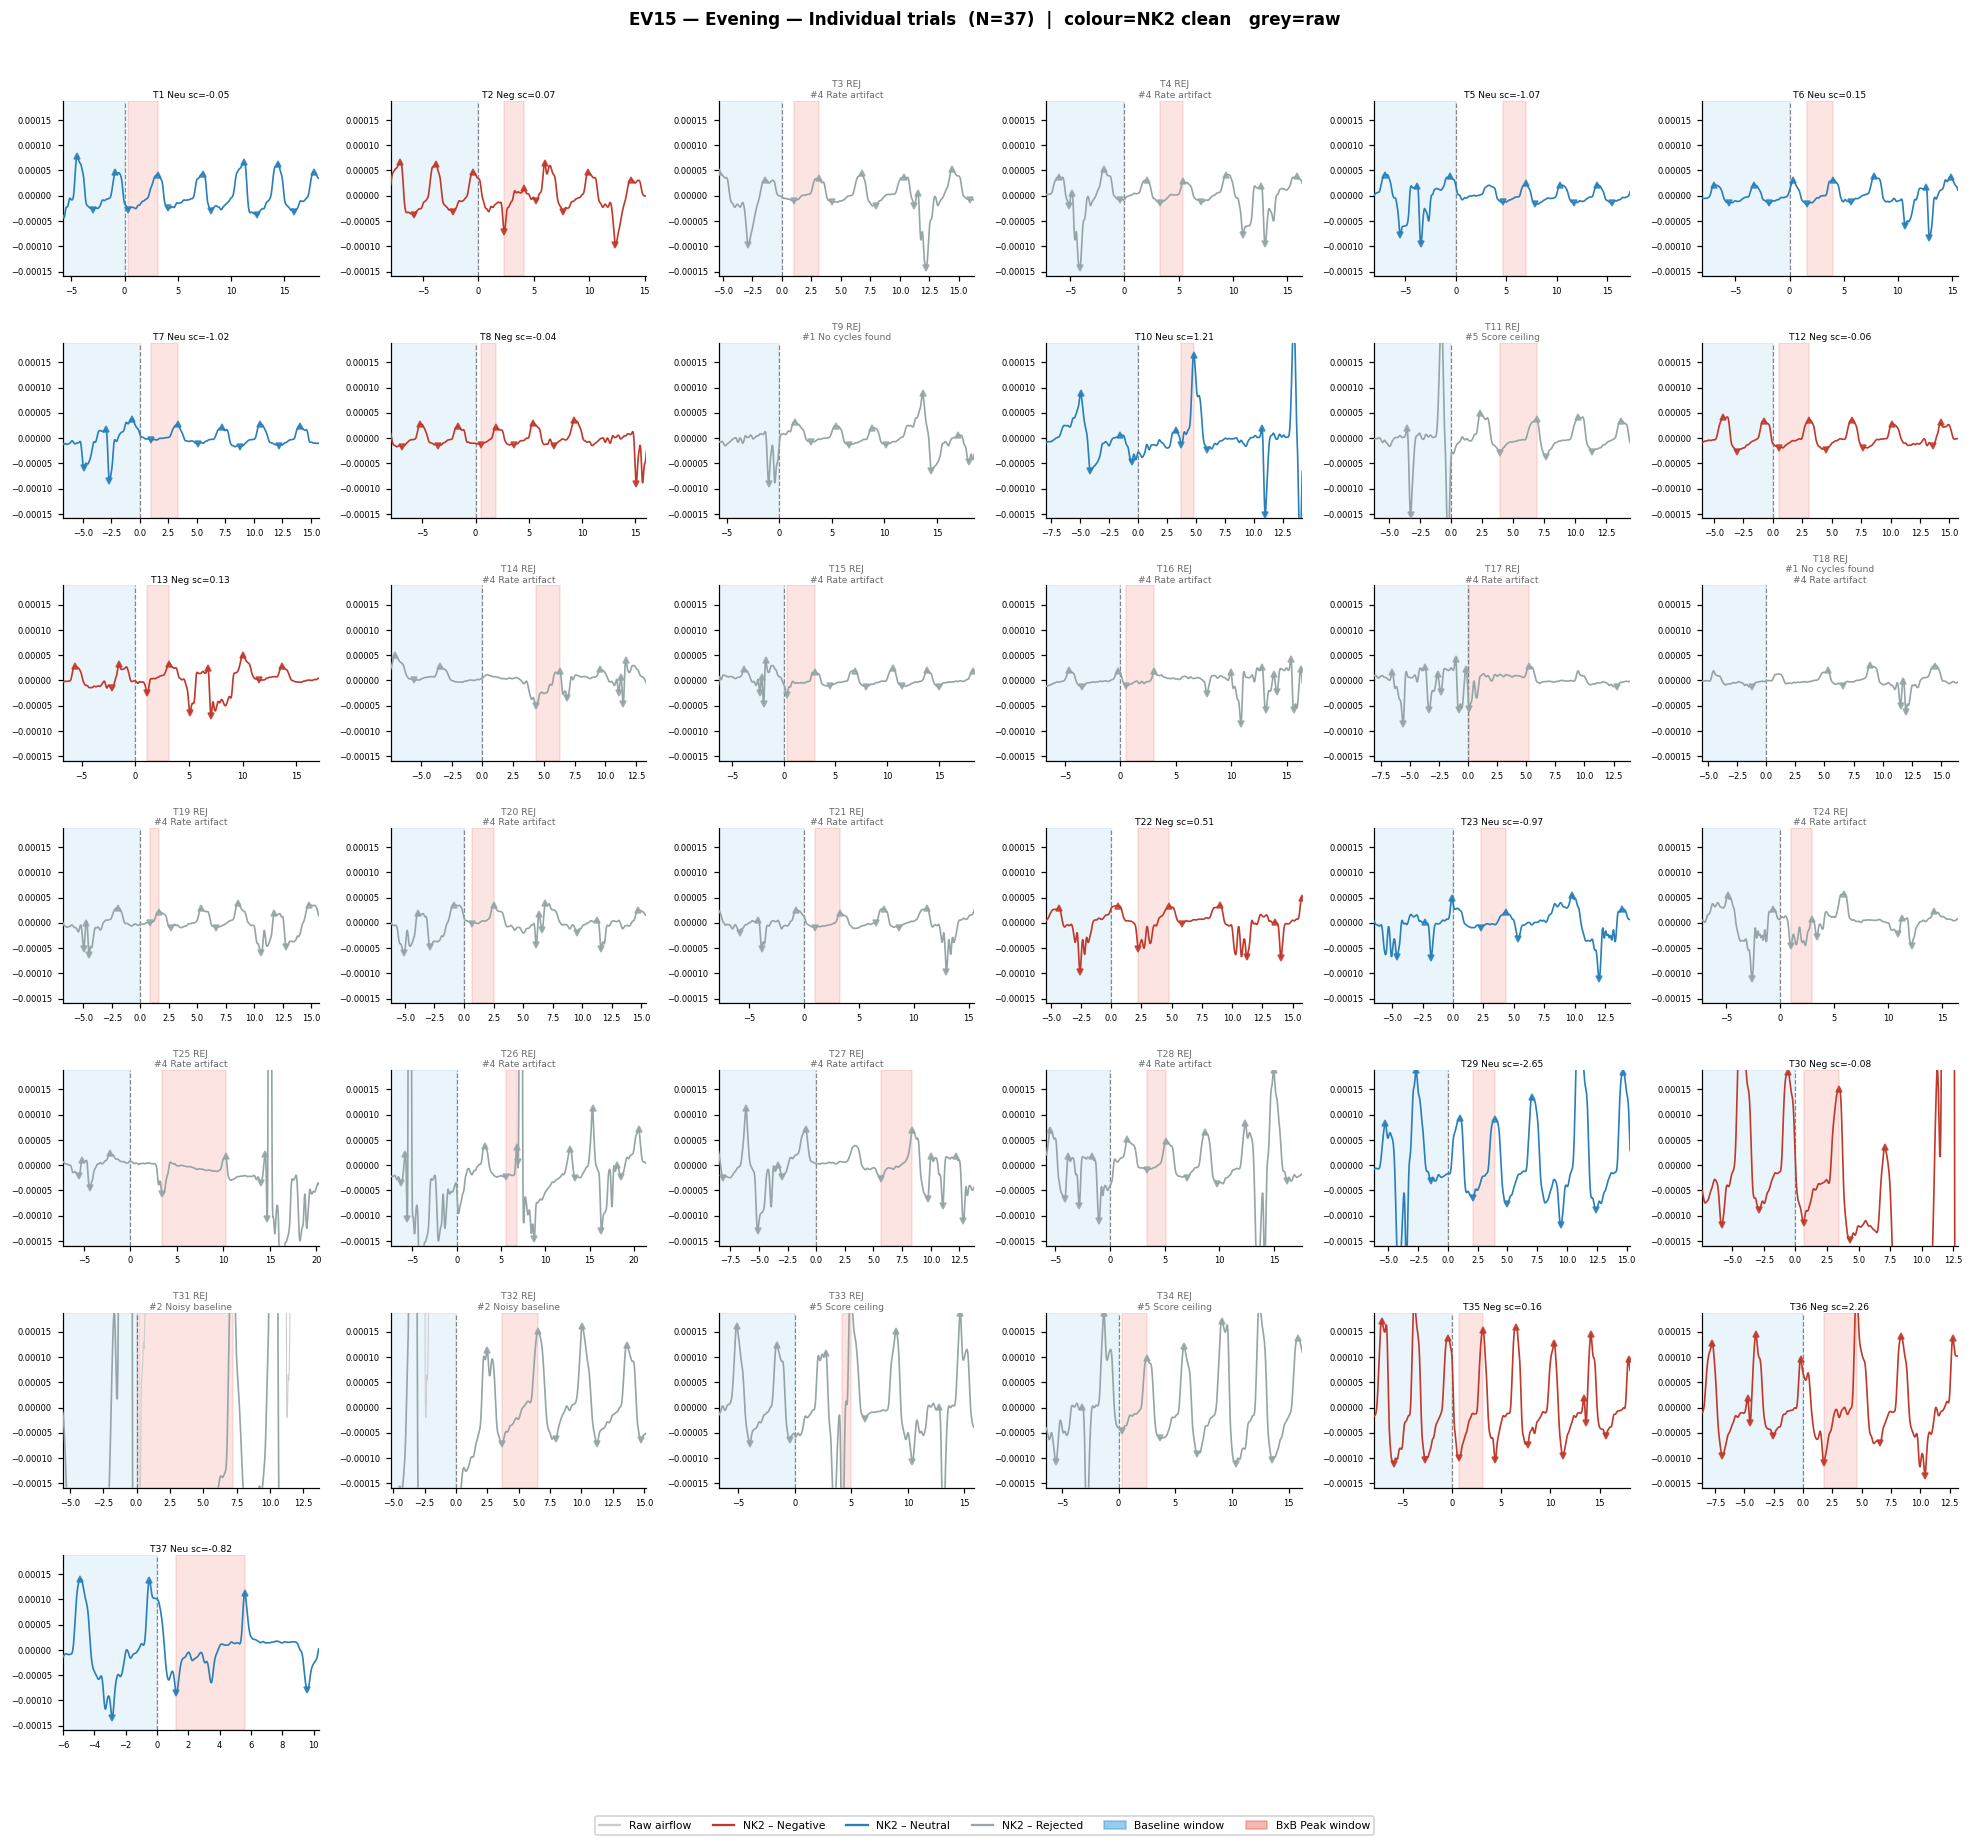

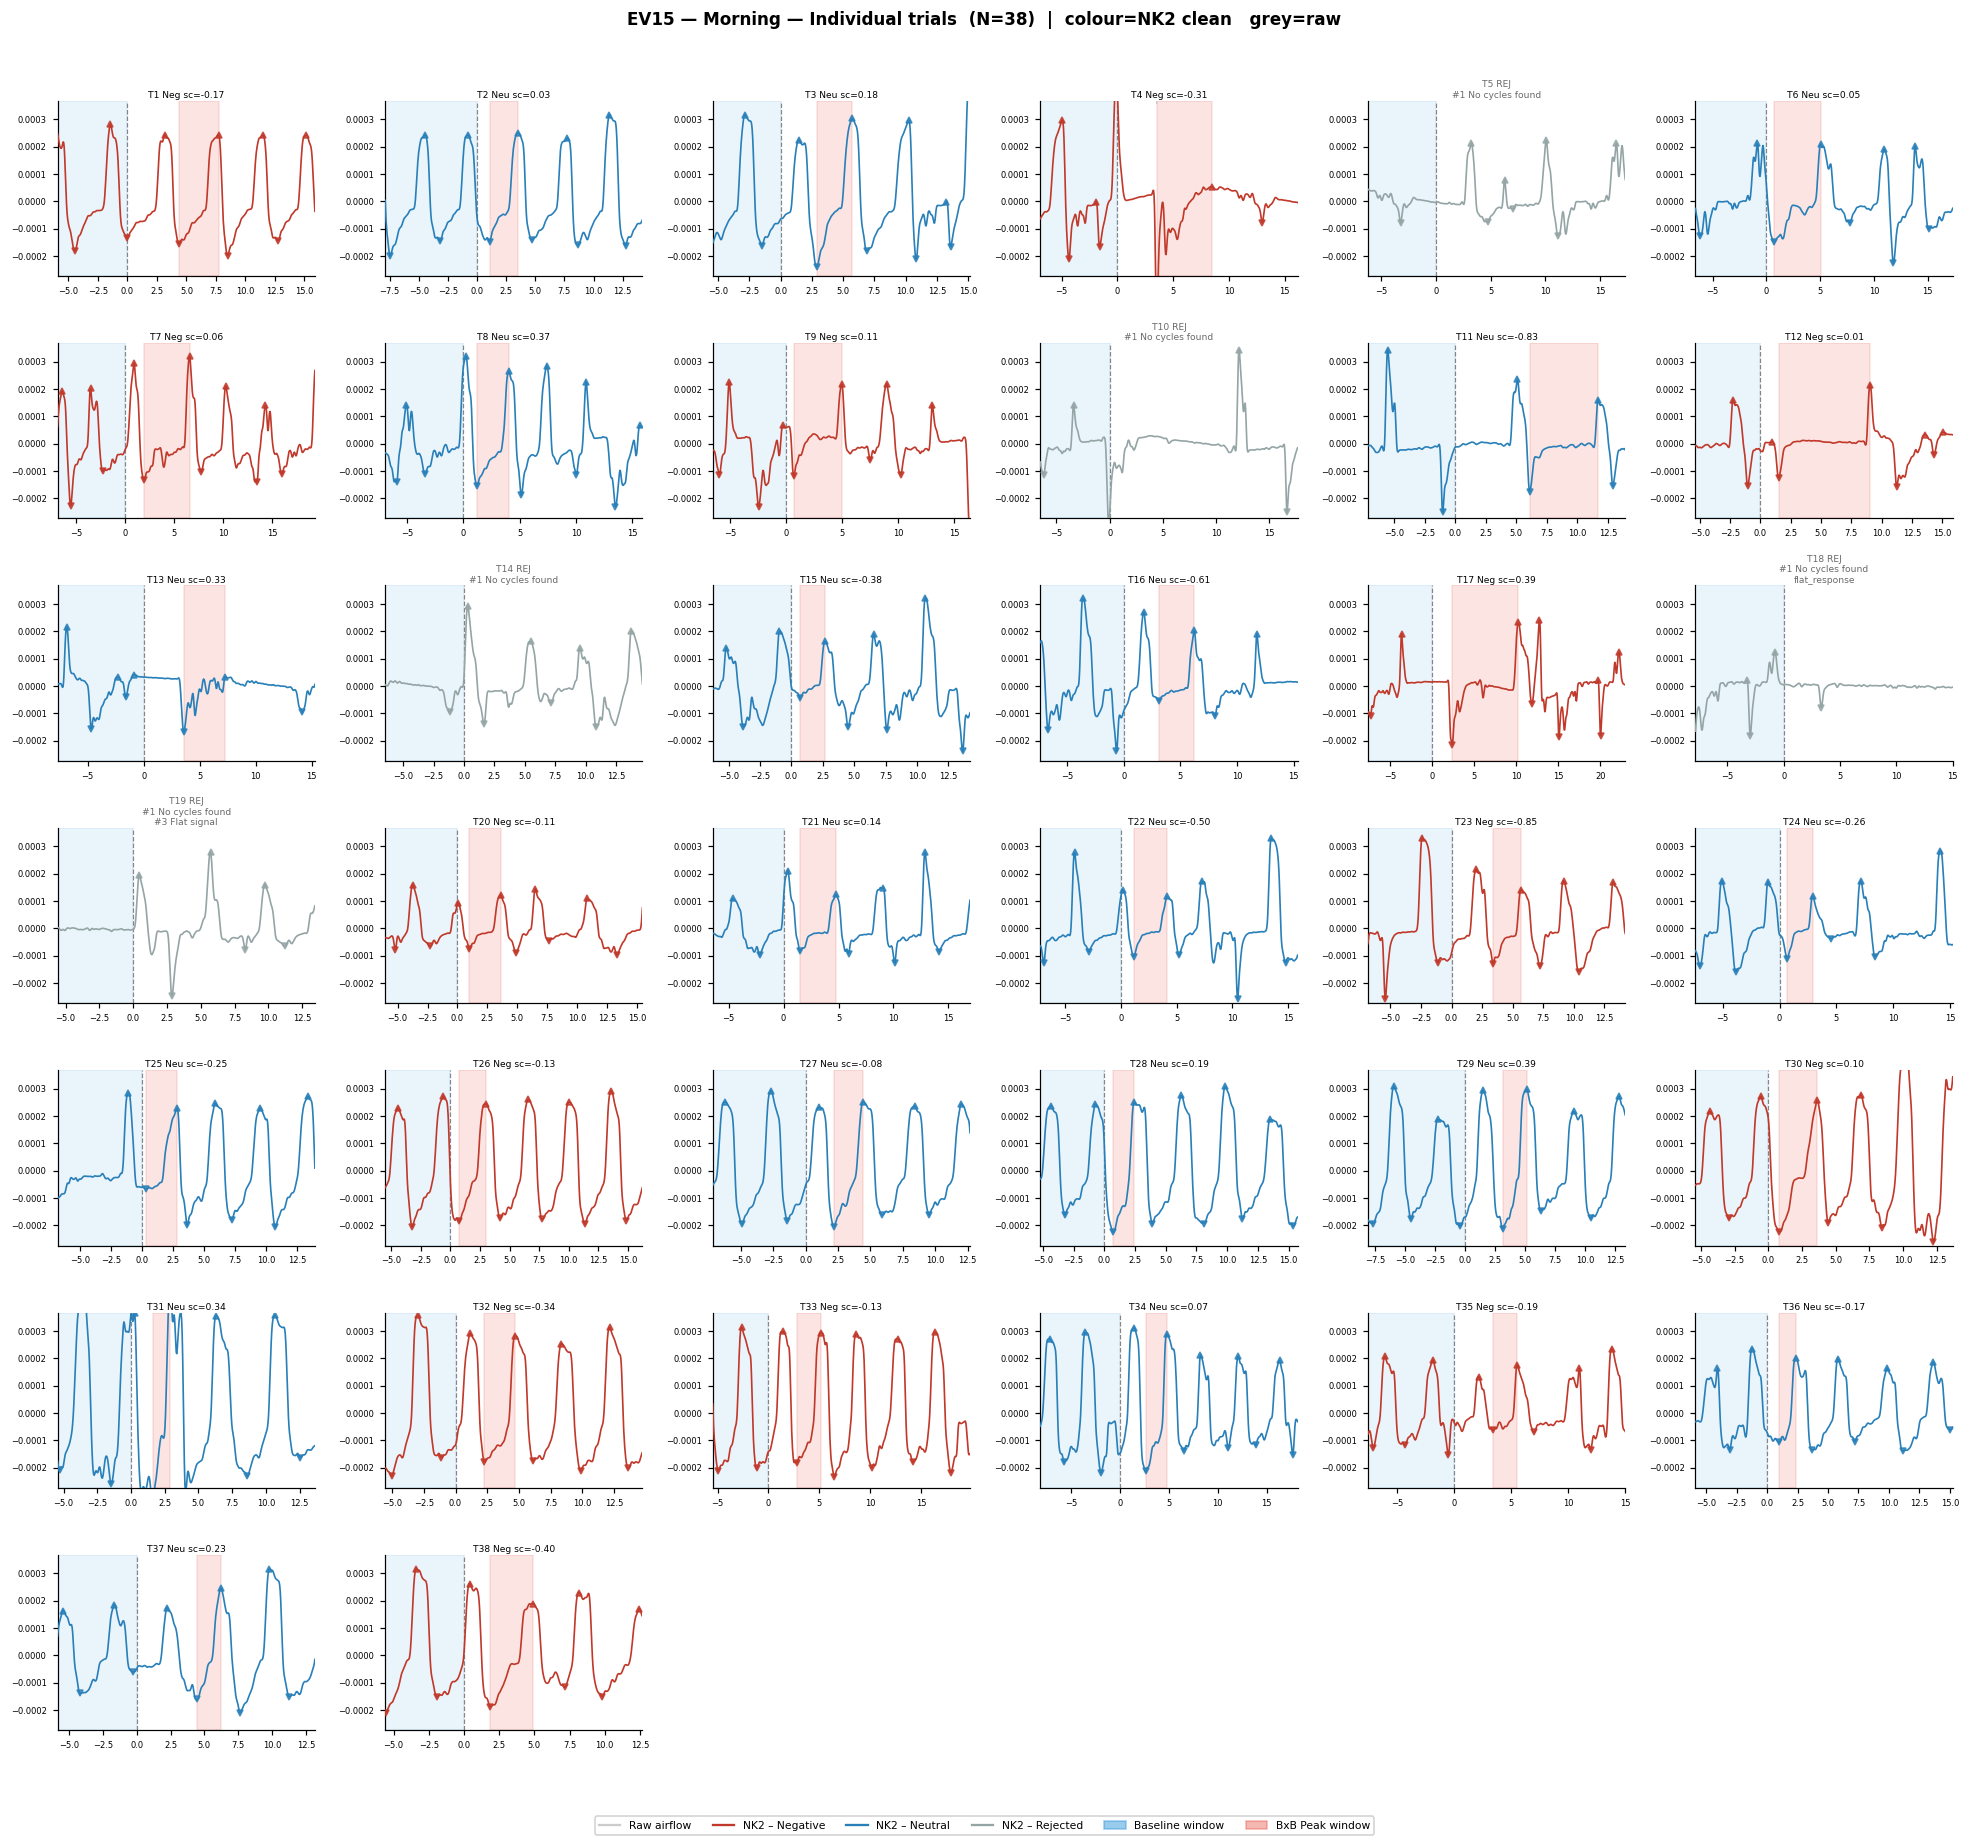

In [30]:
label_name = {1: 'Neg', 2: 'Neu'}
label_col  = {1: config.NEG_COLOR, 2: config.NEU_COLOR}

REJ_LABELS = {
    'no_cycles_found':   '#1 No cycles found',
    'noisy_baseline':    '#2 Noisy baseline',
    'flat_signal':       '#3 Flat signal',
    'rate_artifact':     '#4 Rate artifact',
    'score_ceiling':     '#5 Score ceiling',
    'atypical_shape':    '#6 Shape outlier',
}

def _fmt_reason(rr):
    parts = [REJ_LABELS.get(r.strip(), r.strip()) for r in rr.split(',') if r.strip()]
    return '\n'.join(parts)

for sess_key in sess_keys:
    trials = trials_data[SUBJECT].get(sess_key, [])

    if not trials:
        continue
    sess_label = config.SESSION_MAP.get(sess_key, {}).get('label', sess_key)

    # Collect robust ylim from accepted trials in this session
    accepted_vals = []
    for t_val in trials:
        if not t_val.get('rejected') and t_val.get('epoch_clean_wide') is not None:
            accepted_vals.append(t_val['epoch_clean_wide'])
    if accepted_vals:
        flat = np.concatenate(accepted_vals)
        ylo, yhi = np.percentile(flat, 2), np.percentile(flat, 98)
        margin = max((yhi - ylo) * 0.15, np.abs(yhi) * 0.05)
        ylim = (ylo - margin, yhi + margin)
    else:
        ylim = (-1, 1)

    n     = len(trials)
    nrows = max(1, (n + NCOLS - 1) // NCOLS)
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 3.0, nrows * 2.4),
                             squeeze=False)
    axes_flat = axes.flatten()

    for i, t in enumerate(trials):
        ax        = axes_flat[i]
        tw        = t['times_wide'].astype(float)
        ep_raw    = t['epoch_raw_wide'].astype(float)
        ep_clean  = t.get('epoch_clean_wide')
        ep_peaks  = t.get('ep_peaks',   np.array([], dtype=int))
        ep_troughs= t.get('ep_troughs', np.array([], dtype=int))
        rej       = t.get('rejected')
        lbl       = t.get('label', 0)
        sc        = t.get('score')
        rr        = t.get('rejection_reason', '')

        # Extract BxB bounds
        bxb_tmin = t.get('response_trough_time')
        bxb_tmax = t.get('response_peak_time')

        if rej:
            nk2_col = '#95A5A6';  title_col = 'dimgray'
        else:
            nk2_col = label_col.get(lbl, '#95A5A6');  title_col = 'black'

        ax.plot(tw, ep_raw, color='#CCCCCC', lw=0.7, zorder=2, label='raw')

        if show_nk2 and ep_clean is not None:
            ax.plot(tw, ep_clean.astype(float), color=nk2_col, lw=1.1, zorder=3, label='NK2')
            valid_pk = ep_peaks[(ep_peaks >= 0) & (ep_peaks < len(ep_clean))]
            valid_tr = ep_troughs[(ep_troughs >= 0) & (ep_troughs < len(ep_clean))]
            if len(valid_pk) > 0:
                ax.plot(tw[valid_pk],  ep_clean[valid_pk],  '^',
                        color=nk2_col, ms=3.5, zorder=4, alpha=0.8)
            if len(valid_tr) > 0:
                ax.plot(tw[valid_tr], ep_clean[valid_tr], 'v',
                        color=nk2_col, ms=3.5, zorder=4, alpha=0.8)

        # Draw baseline window
        ax.axvspan(tw[0], 0.0, alpha=0.10, color='#3498DB', zorder=0)  # ground truth: tw<0 is baseline

        # Draw the BxB response window (from chosen trough to peak)
        if bxb_tmin is not None and bxb_tmax is not None and not np.isnan(bxb_tmin) and not np.isnan(bxb_tmax):
            ax.axvspan(bxb_tmin, bxb_tmax, alpha=0.15, color='#E74C3C', zorder=0)

        # Vertical indicator for trigger onset
        ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.45)

        ax.set_xlim(tw[0], tw[-1])
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=5.5)
        ax.spines[['top', 'right']].set_visible(False)

        if rej:
            reason_str = _fmt_reason(rr) or '?'
            # For atypical_shape: append the raw MSD score and session cutoff
            # so you can see exactly how far above the threshold this trial sits
            # and decide whether to raise AIRFLOW_SHAPE_SD_THRESHOLD.
            if 'atypical_shape' in rr:
                msd_val = t.get('shape_msd')
                cut_val = t.get('shape_cutoff')
                msd_s = f'{msd_val:.2e}' if msd_val is not None and np.isfinite(float(msd_val)) else '?'
                cut_s = f'{cut_val:.2e}' if cut_val is not None and np.isfinite(float(cut_val)) else '?'
                reason_str += f'\nmsd={msd_s} cut={cut_s}'
            title = f'T{i+1} REJ\n{reason_str}'
        else:
            sc_str = f'{sc:.2f}' if sc is not None and not np.isnan(float(sc)) else '—'
            title  = f'T{i+1} {label_name.get(lbl,"?")} sc={sc_str}'
        ax.set_title(title, fontsize=6.0, color=title_col, pad=2)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    nk2_note = '  |  colour=NK2 clean   grey=raw' if show_nk2 else '  |  raw only'
    fig.suptitle(f'{SUBJECT} — {sess_label} — Individual trials  (N={n}){nk2_note}',
                 fontsize=11, fontweight='bold')

    fig.legend(handles=[
        plt.Line2D([0],[0], color='#CCCCCC', lw=1.5, label='Raw airflow'),
        plt.Line2D([0],[0], color=config.NEG_COLOR, lw=1.5, label='NK2 – Negative'),
        plt.Line2D([0],[0], color=config.NEU_COLOR, lw=1.5, label='NK2 – Neutral'),
        plt.Line2D([0],[0], color='#95A5A6', lw=1.5, label='NK2 – Rejected'),
        mpatches.Patch(color='#3498DB', alpha=0.5, label='Baseline window'),
        mpatches.Patch(color='#E74C3C', alpha=0.4, label='BxB Peak window'),
    ], fontsize=7, loc='lower center', ncol=6, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    if SAVE_FIGS:
        outdir = os.path.join(config.OUTPUT_DIR, 'raw_show', SUBJECT)
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, f'{SUBJECT}_{sess_key}_trials.png'),
                    dpi=config.PLOT_DPI, bbox_inches='tight')
    plt.show()

### View 2 — Full Session Overview

NK2-filtered airflow signal across the entire session.  

* **Green lines** = startle onsets where a trial passed
* **Red lines** = rejected trials

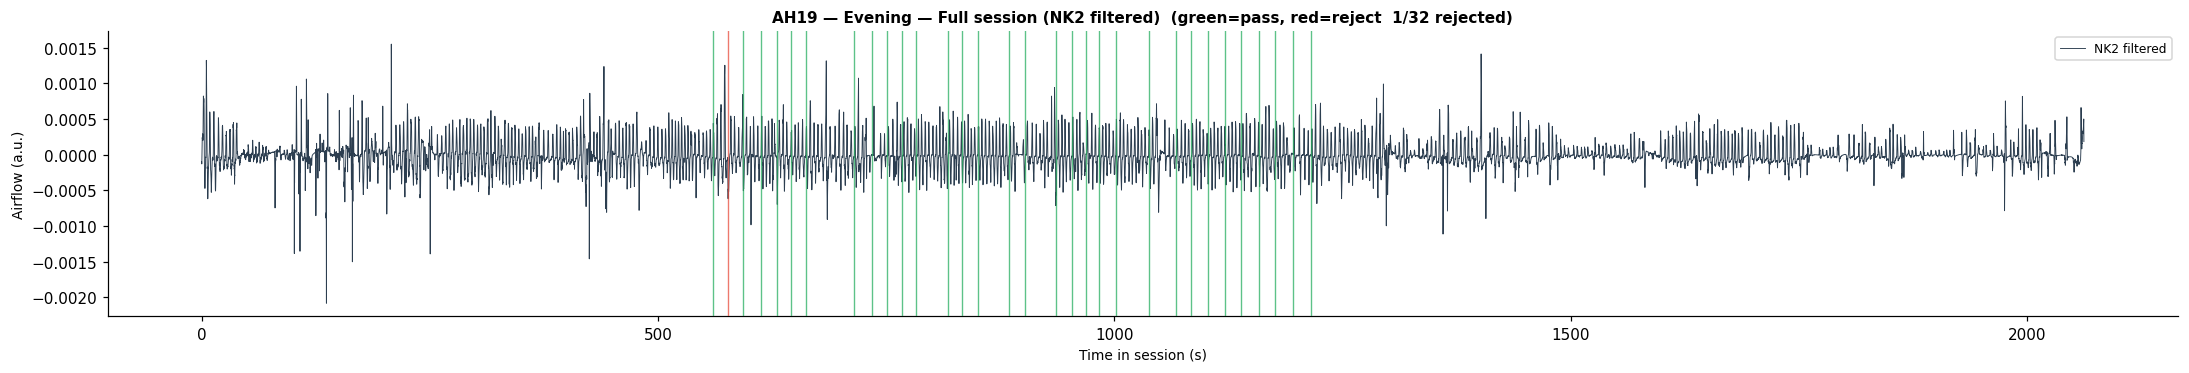

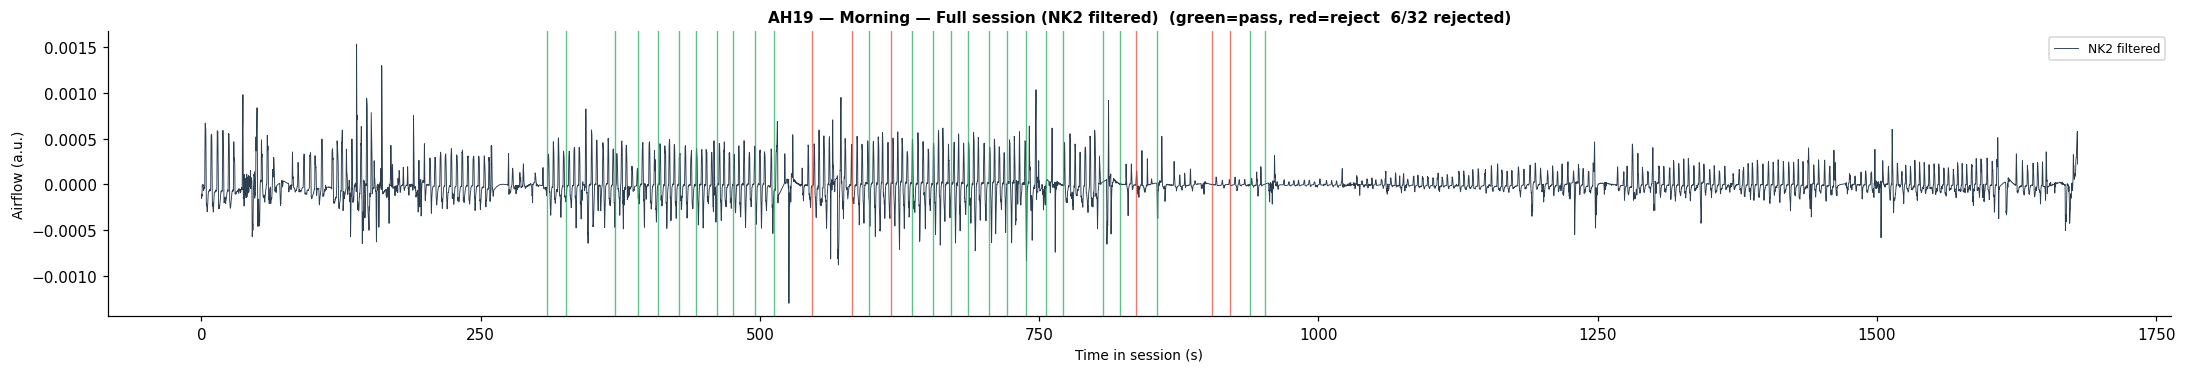

In [22]:
for sess_key in sess_keys:
    trials = trials_data[SUBJECT].get(sess_key, [])
    if not trials:
        continue
    sess_label = config.SESSION_MAP.get(sess_key, {}).get('label', sess_key)

    tr = traces.get(SUBJECT, {}).get(sess_key)
    if tr is None or tr.get('signal') is None:
        print(f'{sess_key}: no session trace — skipping')
        continue

    sig    = tr['signal'].astype(float)
    sfreq  = tr['sfreq']
    t_axis = np.arange(len(sig)) / sfreq

    fig, ax = plt.subplots(figsize=(20, 3.5))
    ax.plot(t_axis, sig, color='#2C3E50', lw=0.6, zorder=2, label='NK2 filtered')

    startle_sec = tr['startle_samps_sec']
    n = min(len(startle_sec), len(trials))
    for idx in range(n):
        t_star = float(startle_sec[idx])
        rej    = trials[idx].get('rejected')
        col    = '#27AE60' if not rej else '#E74C3C'
        ax.axvline(t_star, color=col, lw=0.9, alpha=0.75, zorder=4)

    ax.set_xlabel('Time in session (s)', fontsize=9)
    ax.set_ylabel('Airflow (a.u.)', fontsize=9)
    n_rej = sum(1 for t in trials[:n] if t.get('rejected'))
    ax.set_title(
        f'{SUBJECT} — {sess_label} — Full session (NK2 filtered)  '
        f'(green=pass, red=reject  {n_rej}/{n} rejected)',
        fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

    if SAVE_FIGS:
        outdir = os.path.join(config.OUTPUT_DIR, 'raw_show', SUBJECT)
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, f'{SUBJECT}_{sess_key}_session.png'),
                    dpi=config.PLOT_DPI, bbox_inches='tight')
    plt.show()

---
## Group-Level Plots

All cells below use the full `trials_data` dict (every subject in the cache), not just the subject selected above.

In [23]:

def _sig_label(pval):
    return "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else "ns"))

def _draw_stat_bracket(ax, x1, x2, y_top, pval, test_label, fontsize=10):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015
    ax.plot([x1, x1, x2, x2], [y_top, y_top + h, y_top + h, y_top], lw=1.2, color="black")
    sig = _sig_label(pval)
    ax.text((x1 + x2) / 2, y_top + h * 1.5,
            f"{sig}  {test_label} p={pval:.3f}",
            ha="center", va="bottom", fontsize=fontsize, fontweight="bold")

def _s(t):
    """Return trial score as float, nan if missing/rejected."""
    v = t.get("score")
    if v is None:
        return float("nan")
    try:
        return float(v)
    except Exception:
        return float("nan")

print("Helpers ready.")

Helpers ready.


### View 3 — Trial Score Scatter (per subject)

Trial number vs airflow score, coloured by Neg/Neu. Rejected trials shown as grey ×.

for subj, sessions in sorted(trials_data.items()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"{subj} – Airflow Score by Trial Number", fontsize=13, fontweight="bold")

    for ax, sess_key in zip(axes, ["mor", "eve"]):
        trials = sessions.get(sess_key, [])
        if not trials:
            ax.set_title(f"{sess_key.upper()} – no data"); continue

        scores   = np.array([_s(t) for t in trials])
        labels   = np.array([t.get("label", 0) for t in trials])
        rejected = np.array([bool(t.get("rejected")) for t in trials])
        t_nums   = np.arange(1, len(trials) + 1)

        for cond, color, name in [(1, config.NEG_COLOR, "Negative"), (2, config.NEU_COLOR, "Neutral")]:
            mask = (~rejected) & (labels == cond)
            if mask.sum() > 0:
                ax.scatter(t_nums[mask], scores[mask], color=color,
                           s=60, edgecolors="white", linewidths=0.5, zorder=3,
                           label=f"{name} (n={mask.sum()})")
        n_rej = rejected.sum()
        if n_rej > 0:
            ax.scatter(t_nums[rejected], np.zeros(n_rej),
                       color="#95A5A6", marker="x", s=80, zorder=2,
                       label=f"Rejected (n={n_rej})")

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)
        ax.set_title(sess_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Trial number")
        if ax is axes[0]:
            ax.set_ylabel("Airflow Score (gasp ratio)")
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

### View 4 — Subject Average Timecourse

Per-subject mean ±SEM timecourse for Negative (red) and Neutral (blue), Evening | Morning side by side. Signal is `epoch_anal` baseline-corrected by `baseline_mean`.

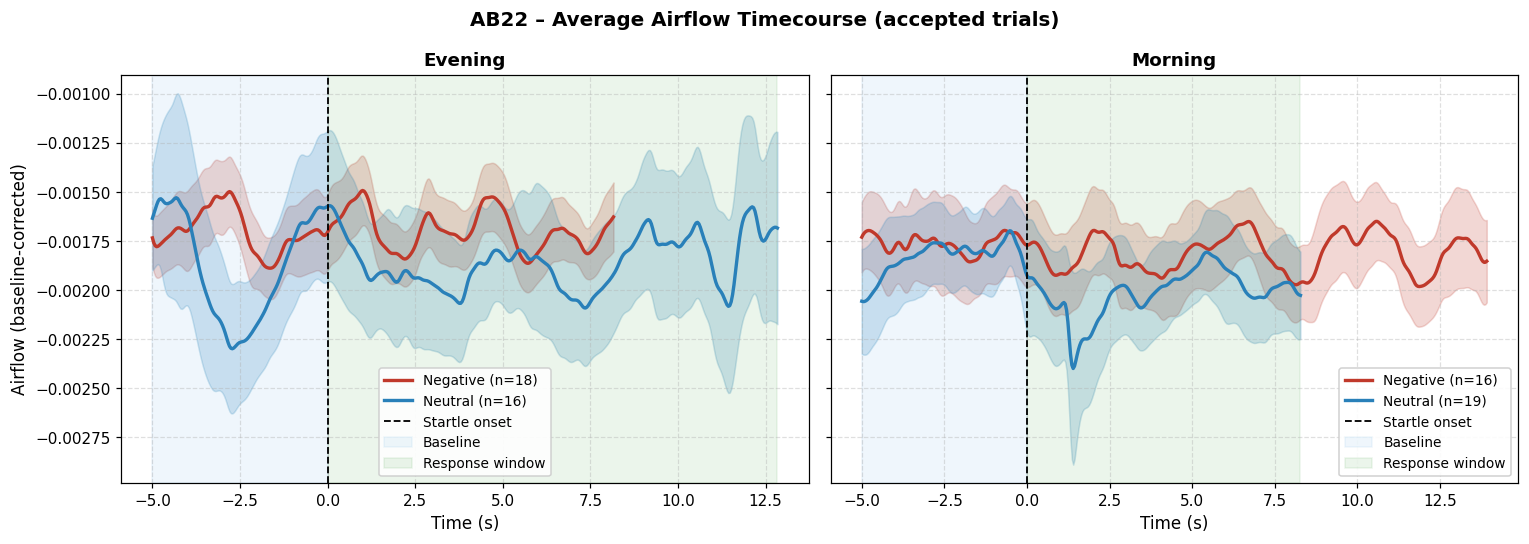

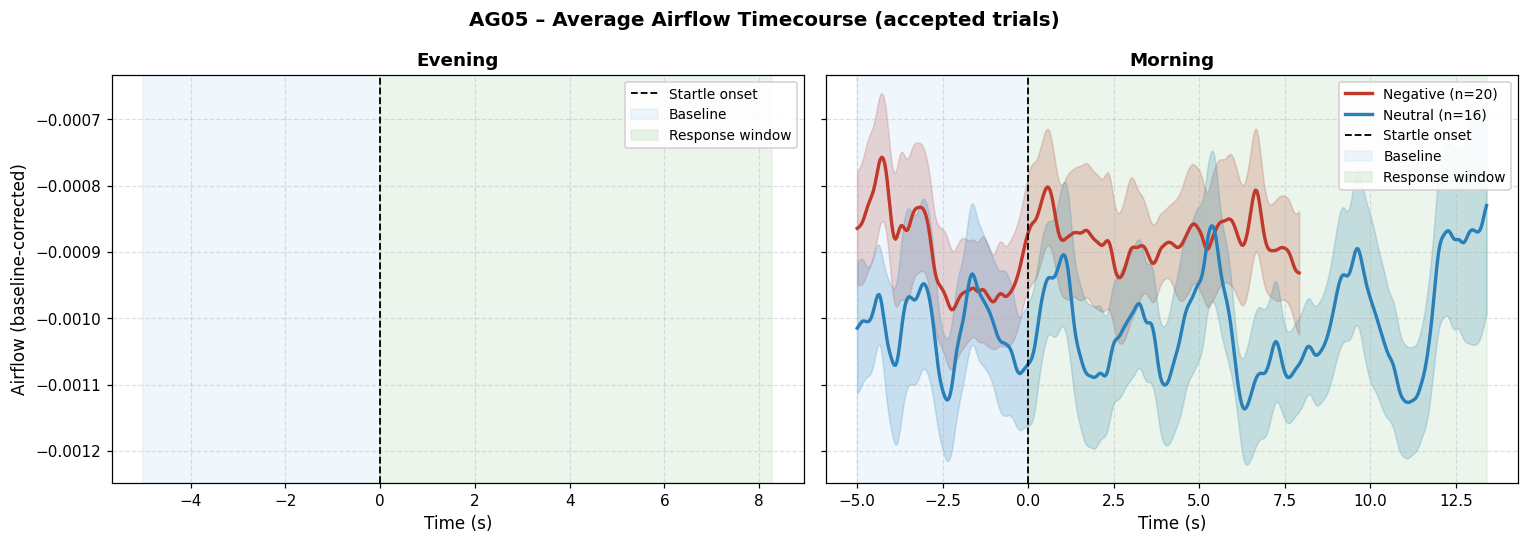

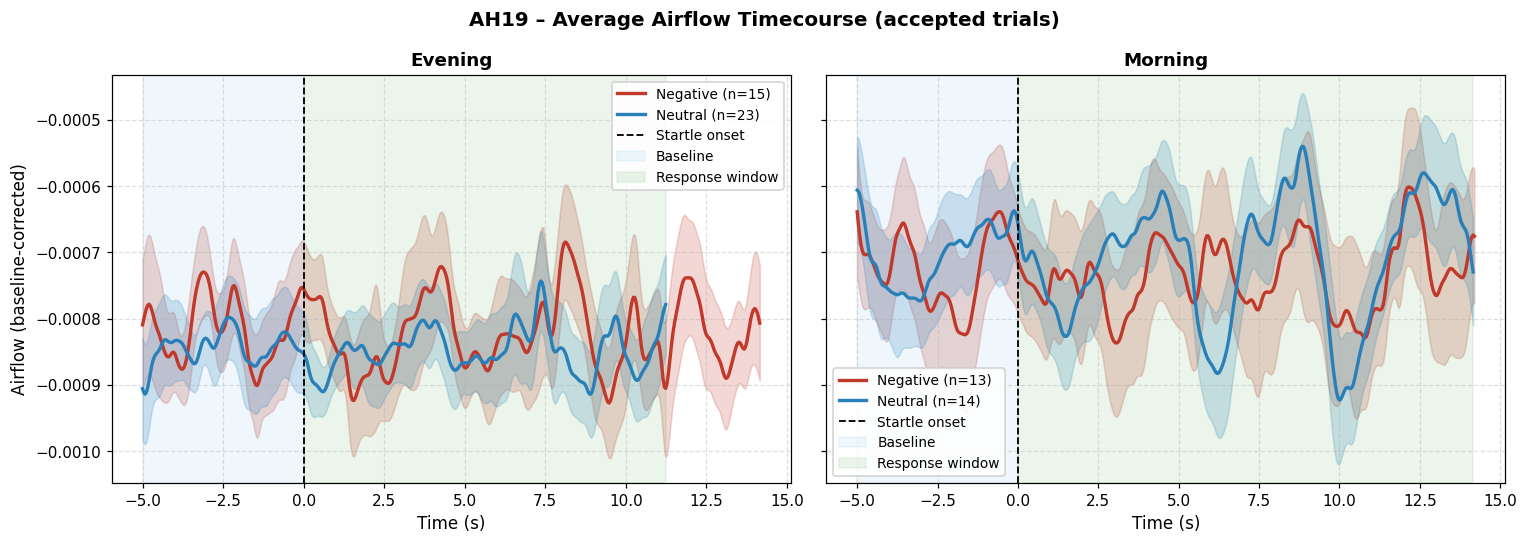

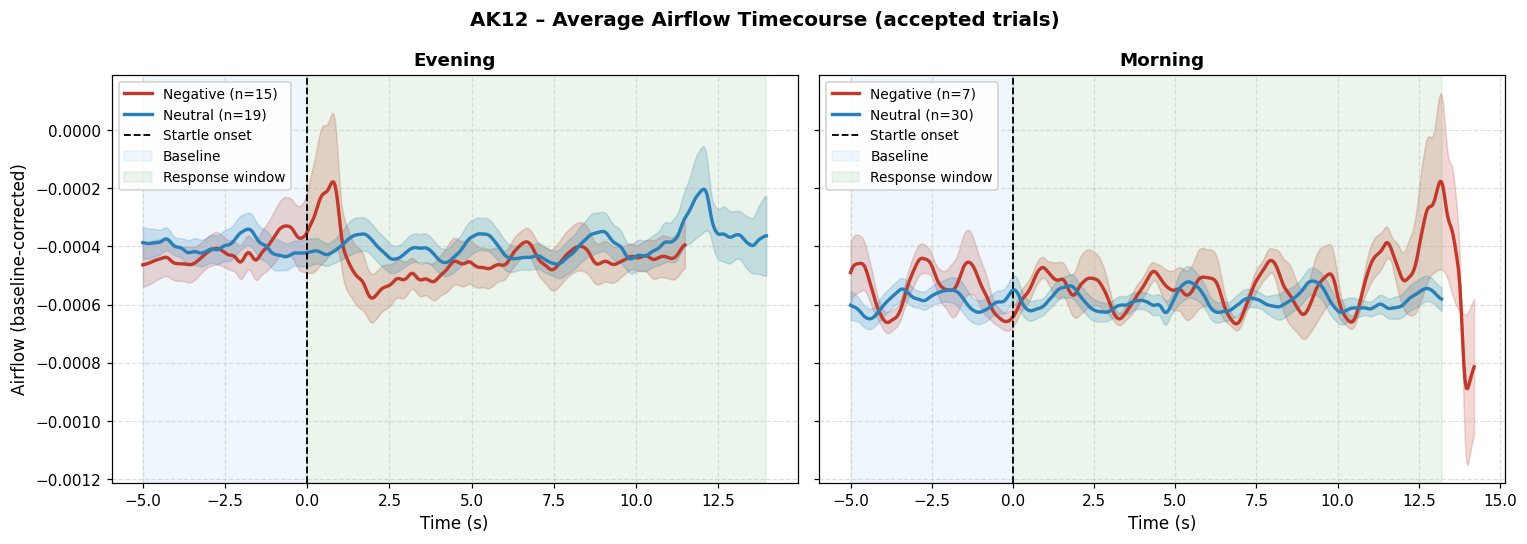

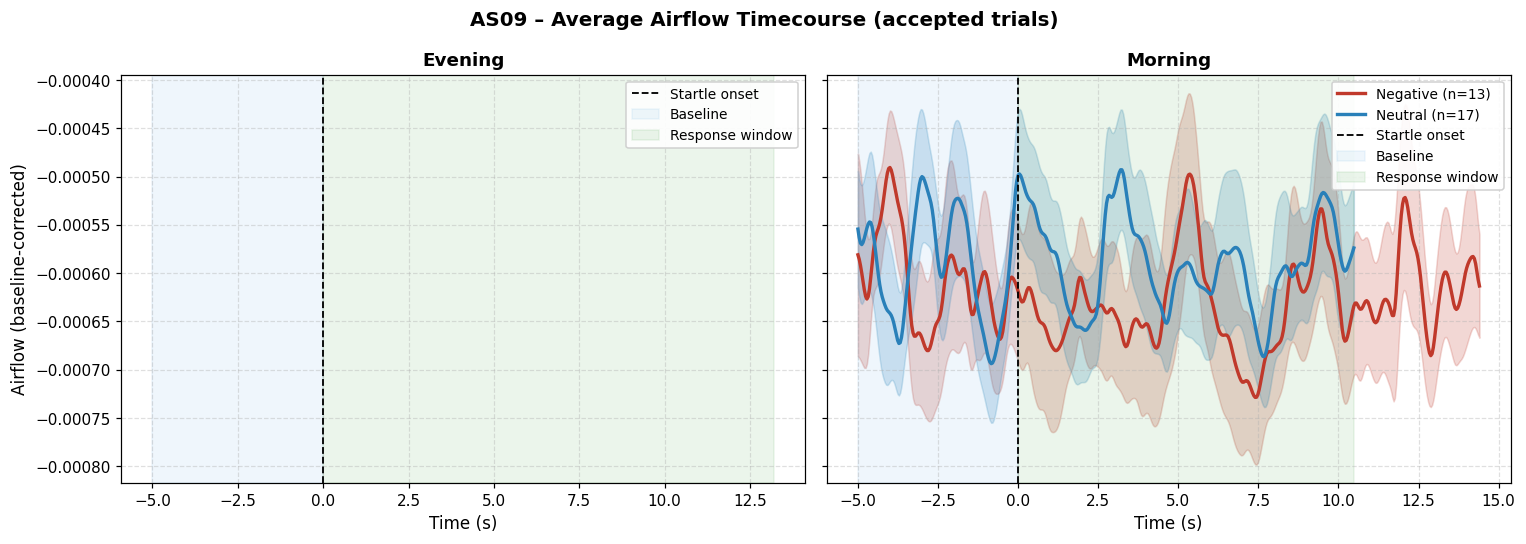

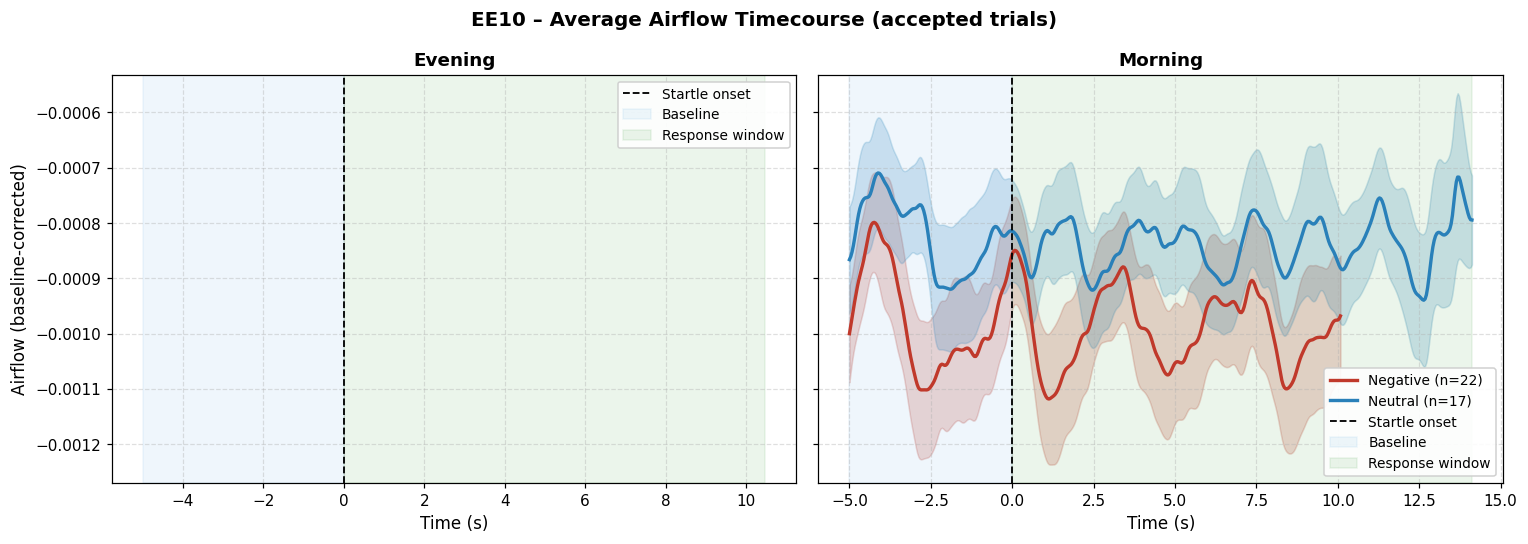

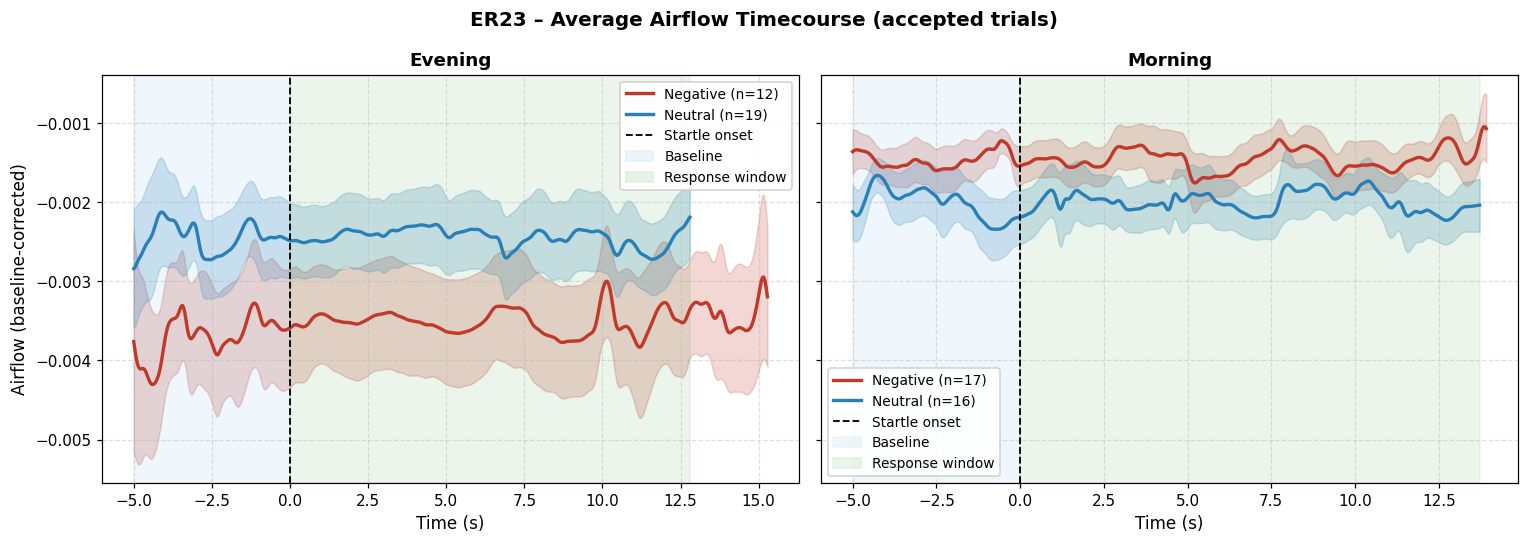

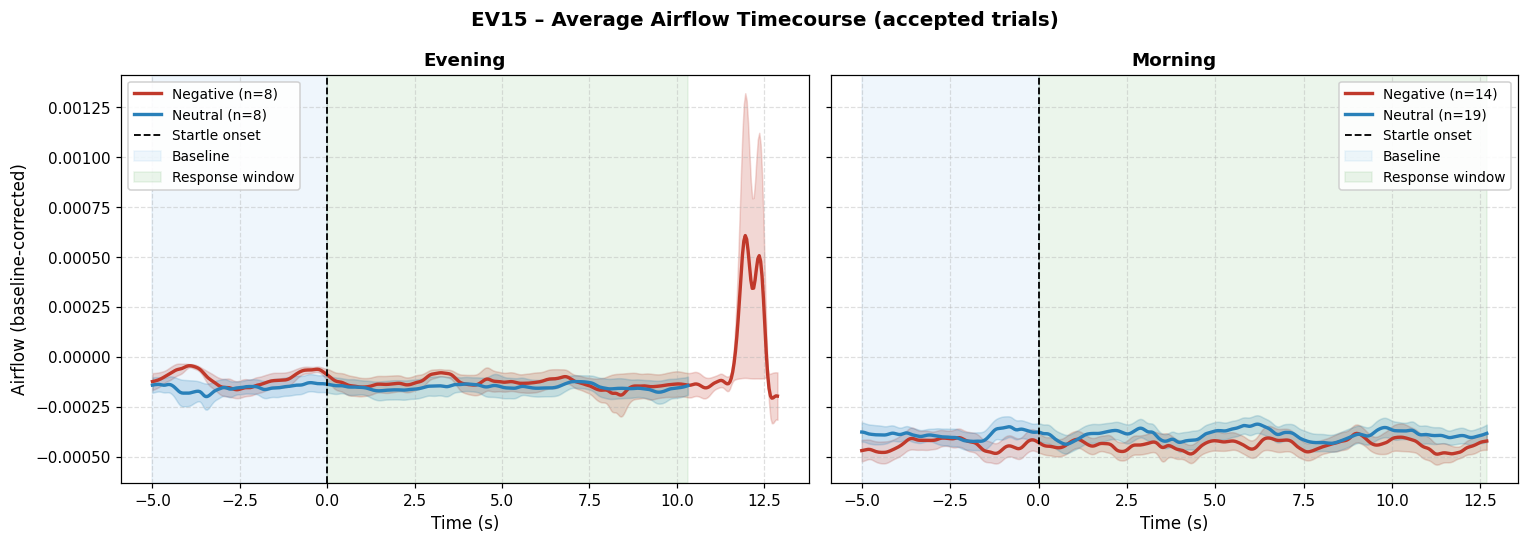

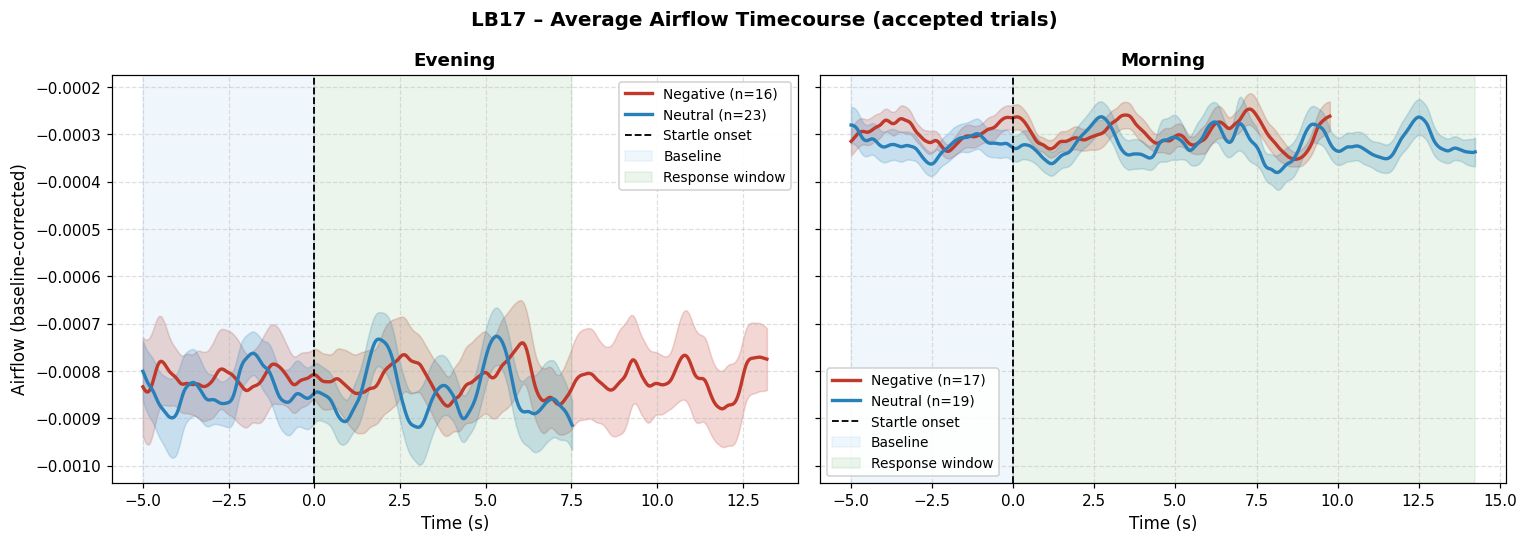

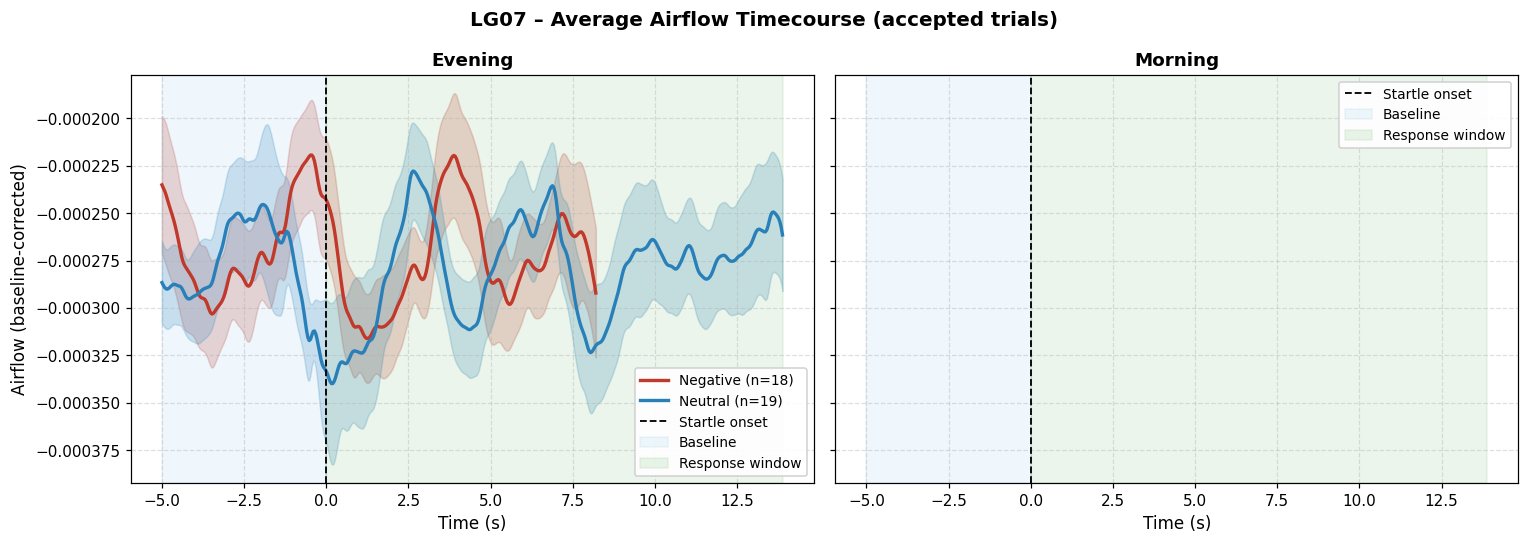

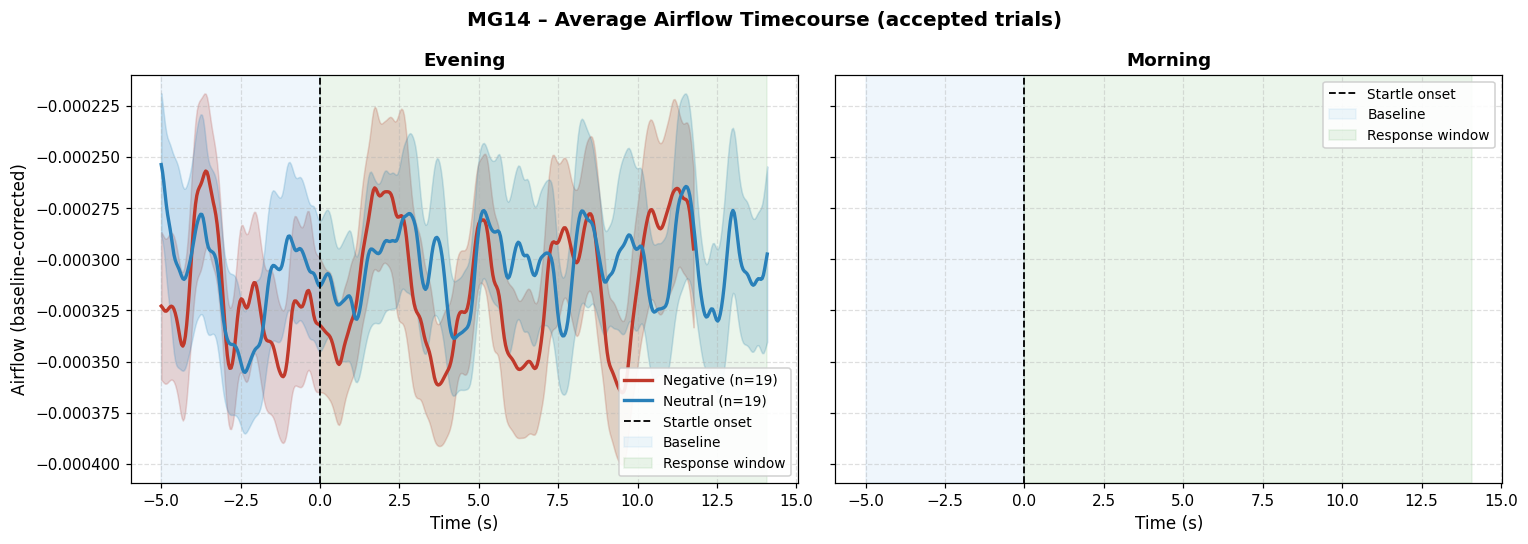

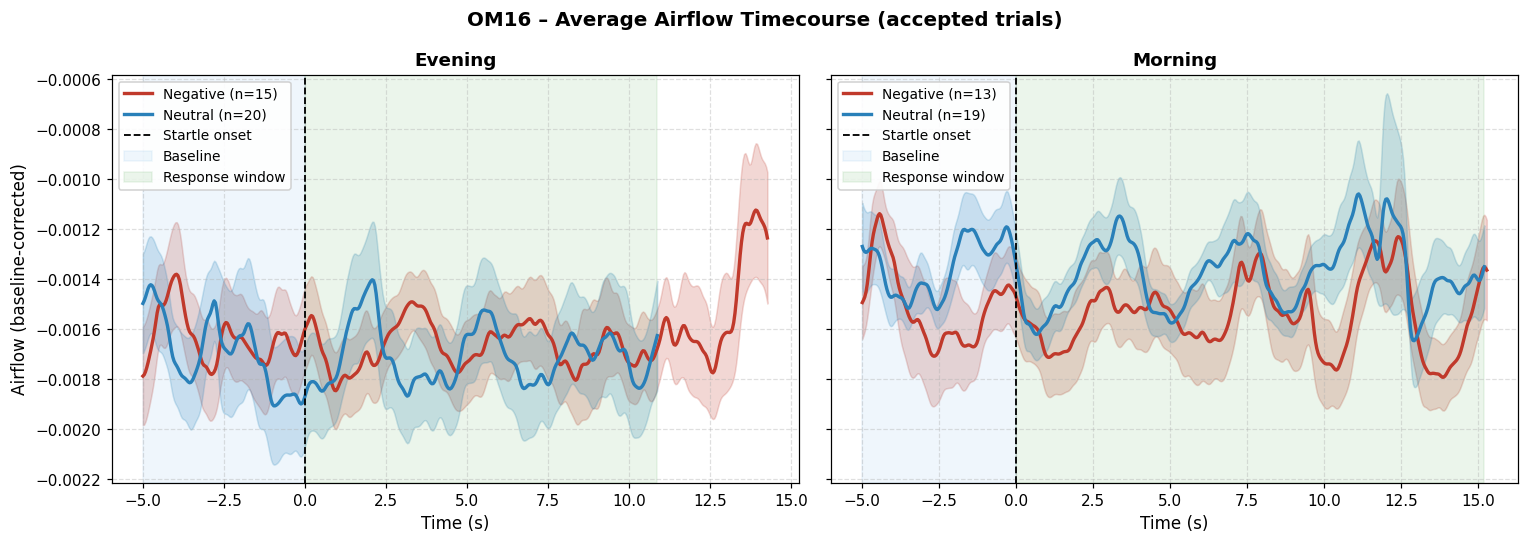

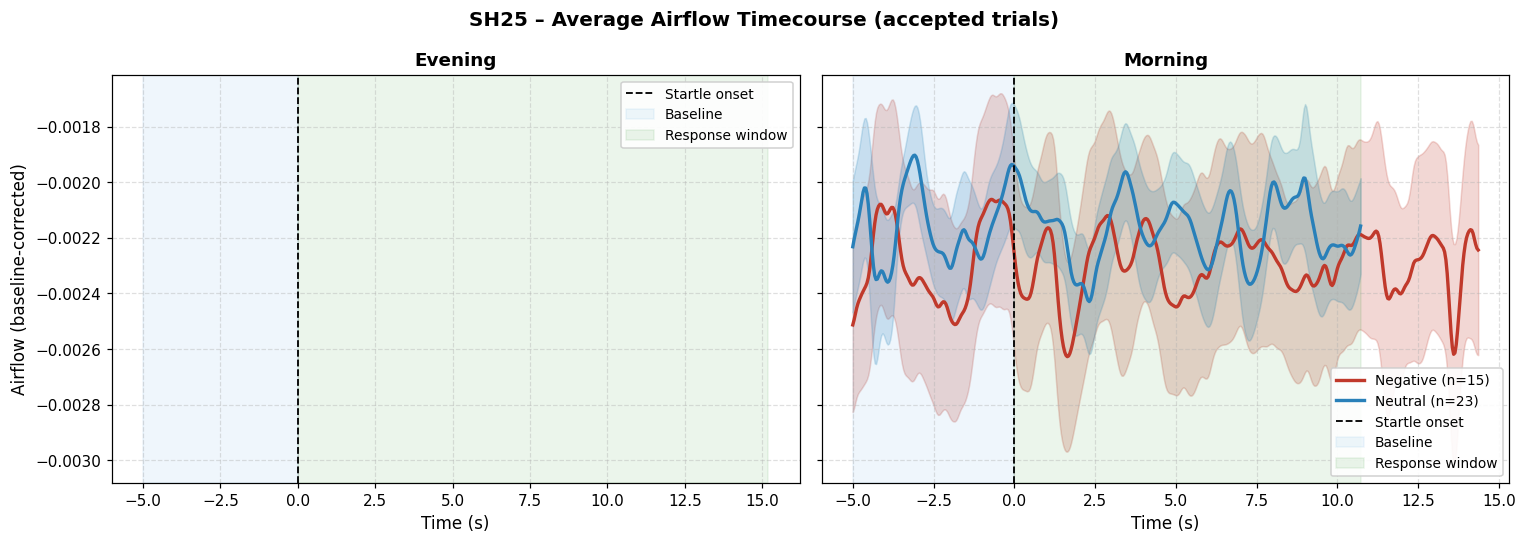

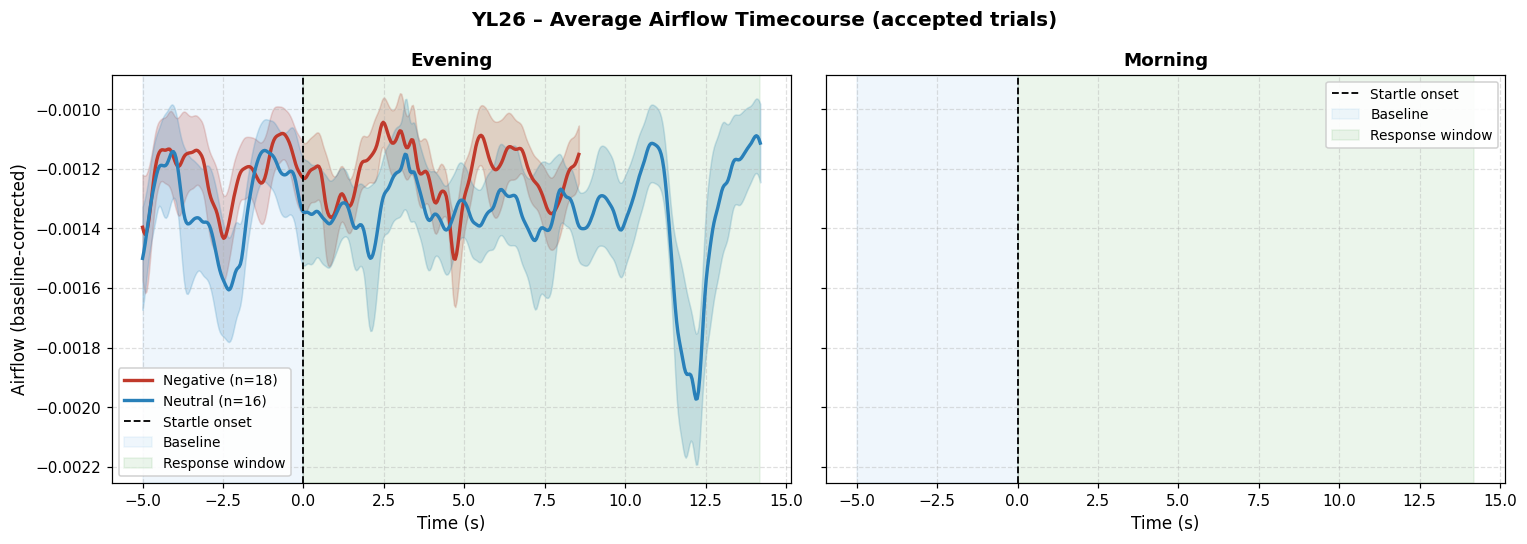

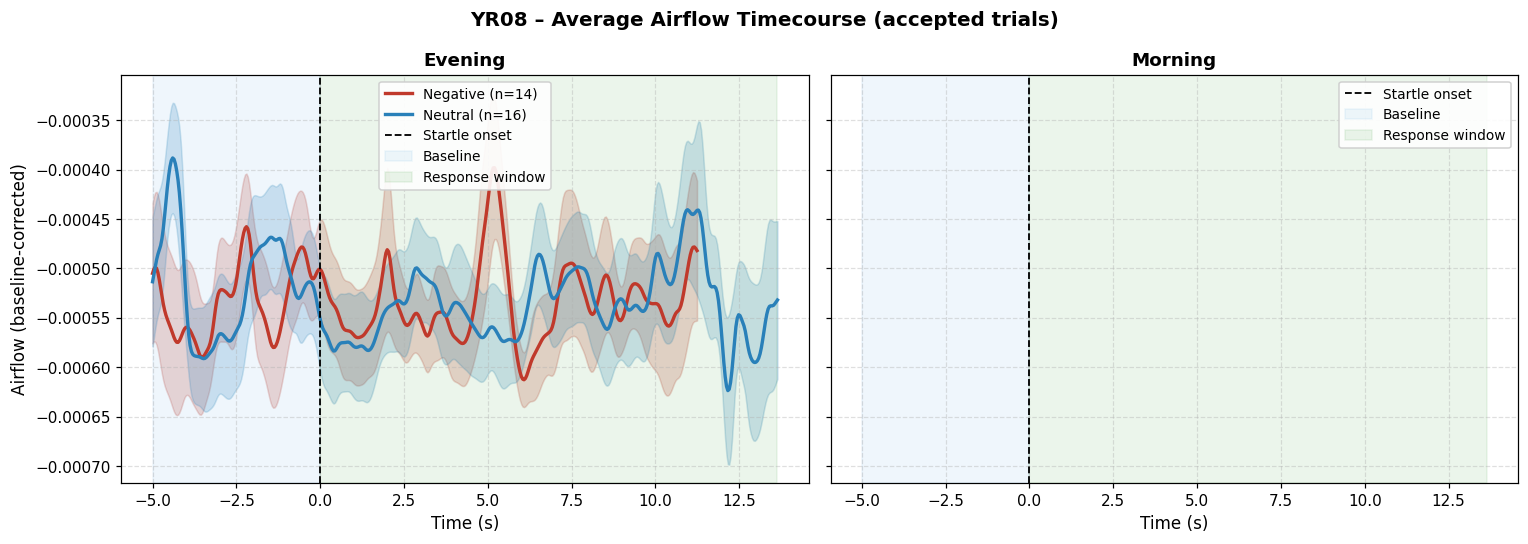

In [25]:
for subj, sessions in sorted(trials_data.items()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"{subj} – Average Airflow Timecourse (accepted trials)",
                 fontsize=13, fontweight="bold")
    has_data = False

    for ax, sess_key in zip(axes, ["eve", "mor"]):
        sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)
        trials = sessions.get(sess_key, [])

        for cond, color, name in [(1, config.NEG_COLOR, "Negative"), (2, config.NEU_COLOR, "Neutral")]:
            cond_trials = [
                t for t in trials
                if not t.get("rejected")
                and t.get("epoch_anal") is not None
                and t.get("baseline_mean") is not None
                and t.get("label") == cond
            ]
            if not cond_trials:
                continue
            has_data = True
            epochs = [t["epoch_anal"] - t["baseline_mean"] for t in cond_trials]
            n = min(len(e) for e in epochs)
            arr = np.array([e[:n] for e in epochs])
            avg = np.mean(arr, axis=0)
            sem = _stats.sem(arr, axis=0, nan_policy="omit") if len(epochs) > 1 else np.zeros_like(avg)
            # Epoch length varies per trial (ground-truth trial_epochs span,
            # not a fixed WIDE_TMIN/TMAX window) -- take the time axis from
            # whichever trial in THIS group is shortest, not an unrelated
            # reference trial, so it always matches avg's length exactly.
            shortest = min(cond_trials, key=lambda t: len(t["epoch_anal"]))
            times_s = shortest["times_anal"][:n]

            ax.plot(times_s, avg, color=color, linewidth=2.2,
                    label=f"{name} (n={len(epochs)})")
            if len(epochs) > 1:
                ax.fill_between(times_s, avg - sem, avg + sem, color=color, alpha=0.20)

        ax.axvline(0, color="k", linestyle="--", linewidth=1.2, label="Startle onset")
        ax.axvspan(times_s[0], 0.0,
                   color="#3498DB", alpha=0.08, label="Baseline")  # ground truth: t<0
        ax.axvspan(0.0, times_s[-1],
                   color="green", alpha=0.08, label="Response window")  # ground truth: t>=0
        ax.set_title(sess_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Time (s)", fontsize=11)
        if ax is axes[0]:
            ax.set_ylabel("Airflow (baseline-corrected)", fontsize=11)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(True, linestyle="--", alpha=0.4)

    if has_data:
        plt.tight_layout()
        plt.show()
    plt.close(fig)

### View 5 — Group Average Timecourse (Neg / Neu split)

Grand mean ±SEM per session (Evening left, Morning right). Negative = red, Neutral = blue. Shaded band = ±SEM across subjects.

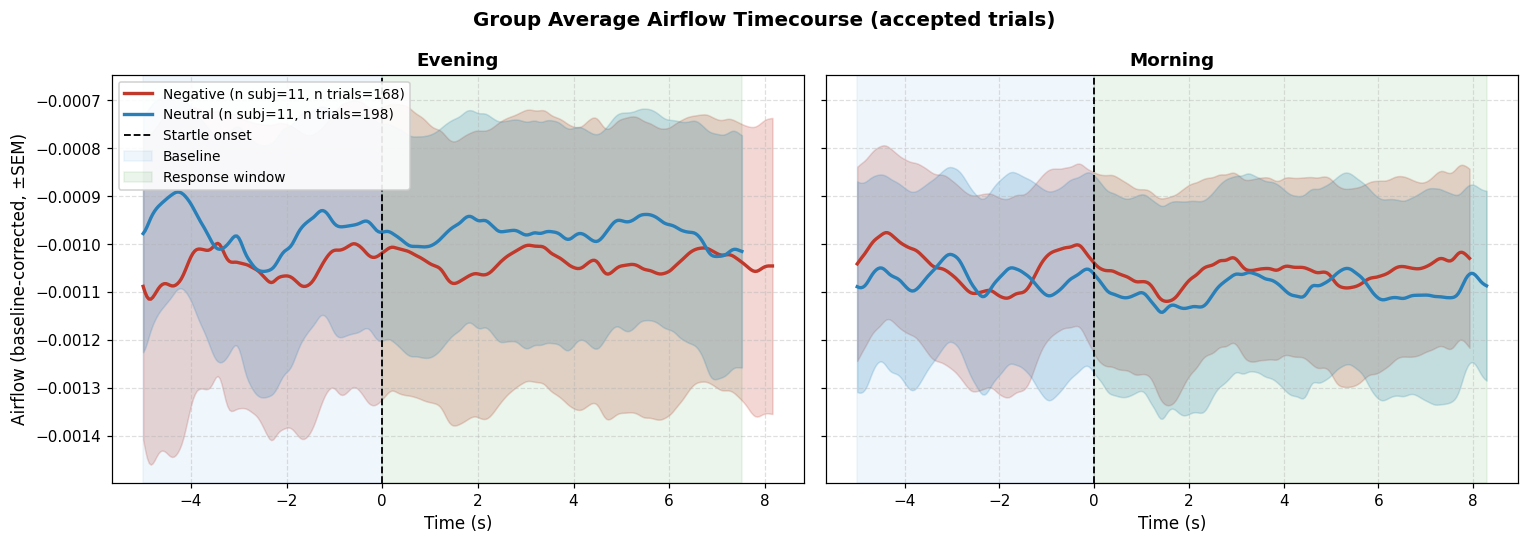

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Group Average Airflow Timecourse (accepted trials)",
             fontsize=13, fontweight="bold")

for ax, sess_key in zip(axes, ["eve", "mor"]):
    sess_label = config.SESSION_MAP.get(sess_key, {}).get("label", sess_key)

    for cond, color, name in [(1, config.NEG_COLOR, "Negative"), (2, config.NEU_COLOR, "Neutral")]:
        subj_avgs = []; subj_times = []; n_subjs_g = 0; n_trials_g = 0

        for subj, sessions in trials_data.items():
            trials = sessions.get(sess_key, [])
            cond_trials = [
                t for t in trials
                if not t.get("rejected")
                and t.get("epoch_anal") is not None
                and t.get("baseline_mean") is not None
                and t.get("label") == cond
            ]
            if cond_trials:
                epochs = [t["epoch_anal"] - t["baseline_mean"] for t in cond_trials]
                n_subj = min(len(e) for e in epochs)
                subj_avgs.append(np.mean([e[:n_subj] for e in epochs], axis=0))
                shortest = min(cond_trials, key=lambda t: len(t["epoch_anal"]))
                subj_times.append(shortest["times_anal"][:n_subj])
                n_subjs_g += 1; n_trials_g += len(epochs)

        if not subj_avgs:
            continue
        # Epoch length varies per subject too (each subject's shortest
        # ground-truth trial_epochs span differs) -- truncate every subject
        # average to the shortest one and take THAT subject's own time axis,
        # not an unrelated reference, so ts always matches avg's length.
        n = min(len(a) for a in subj_avgs)
        shortest_i = int(np.argmin([len(a) for a in subj_avgs]))
        arr = np.array([a[:n] for a in subj_avgs])
        avg = np.mean(arr, axis=0)
        sem = _stats.sem(arr, axis=0, nan_policy="omit")
        ts = subj_times[shortest_i][:n]

        ax.plot(ts, avg, color=color, linewidth=2.2,
                label=f"{name} (n subj={n_subjs_g}, n trials={n_trials_g})")
        ax.fill_between(ts, avg - sem, avg + sem, color=color, alpha=0.20)

    ax.axvline(0, color="k", linestyle="--", linewidth=1.2, label="Startle onset")
    ax.axvspan(ts[0], 0.0,
               color="#3498DB", alpha=0.08, label="Baseline")  # ground truth: t<0
    ax.axvspan(0.0, ts[-1],
               color="green", alpha=0.08, label="Response window")  # ground truth: t>=0
    ax.set_title(sess_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Airflow (baseline-corrected, ±SEM)", fontsize=11)
        ax.legend(fontsize=9, framealpha=0.9, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

### View 6 — Group Overall Timecourse (Evening vs Morning)

All accepted trials averaged. Evening = orange, Morning = purple. Shaded band = ±SEM across subjects.

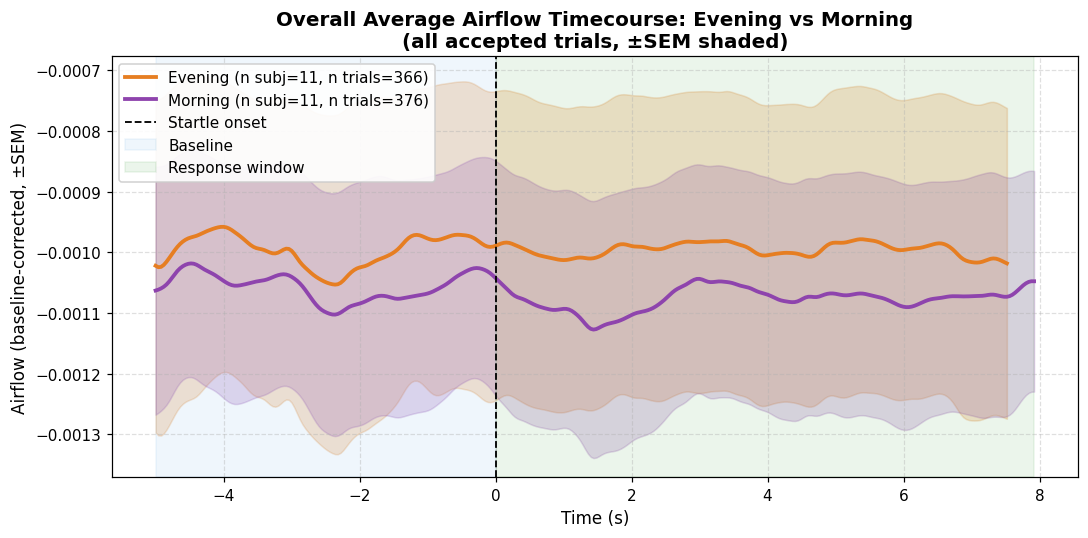

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

for sess_key, sess_label, color in [("eve", "Evening", config.EVE_COLOR),
                                     ("mor", "Morning", config.MOR_COLOR)]:
    subj_avgs = []; subj_times = []; n_subjs_ov = 0; n_trials_ov = 0

    for subj, sessions in trials_data.items():
        trials = sessions.get(sess_key, [])
        cond_trials = [
            t for t in trials
            if not t.get("rejected")
            and t.get("epoch_anal") is not None
            and t.get("baseline_mean") is not None
        ]
        if cond_trials:
            epochs = [t["epoch_anal"] - t["baseline_mean"] for t in cond_trials]
            n_subj = min(len(e) for e in epochs)
            subj_avgs.append(np.mean([e[:n_subj] for e in epochs], axis=0))
            shortest = min(cond_trials, key=lambda t: len(t["epoch_anal"]))
            subj_times.append(shortest["times_anal"][:n_subj])
            n_subjs_ov += 1; n_trials_ov += len(epochs)

    if not subj_avgs:
        continue
    # Epoch length varies per subject (ground-truth trial_epochs span) --
    # truncate every subject average to the shortest one and take THAT
    # subject's own time axis, not an unrelated reference trial.
    n = min(len(a) for a in subj_avgs)
    shortest_i = int(np.argmin([len(a) for a in subj_avgs]))
    arr = np.array([a[:n] for a in subj_avgs])
    avg = np.mean(arr, axis=0)
    sem = _stats.sem(arr, axis=0, nan_policy="omit")
    ts = subj_times[shortest_i][:n]

    ax.plot(ts, avg, color=color, linewidth=2.5,
            label=f"{sess_label} (n subj={n_subjs_ov}, n trials={n_trials_ov})")
    ax.fill_between(ts, avg - sem, avg + sem, color=color, alpha=0.20)

ax.axvline(0, color="k", linestyle="--", linewidth=1.2, label="Startle onset")
ax.axvspan(ts[0], 0.0,
           color="#3498DB", alpha=0.08, label="Baseline")  # ground truth: t<0
ax.axvspan(0.0, ts[-1],
           color="green", alpha=0.08, label="Response window")  # ground truth: t>=0
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Airflow (baseline-corrected, ±SEM)", fontsize=11)
ax.set_title("Overall Average Airflow Timecourse: Evening vs Morning\n"
             "(all accepted trials, ±SEM shaded)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

### View 7 — Group 4-Condition Boxplot

Eve-Neg | Eve-Neu | Mor-Neg | Mor-Neu with scatter overlay and Wilcoxon brackets.

In [ ]:
cond_keys4 = [
    ("eve", 1, "Eve-Neg", config.NEG_COLOR),
    ("eve", 2, "Eve-Neu", config.NEU_COLOR),
    ("mor", 1, "Mor-Neg", "#922B21"),
    ("mor", 2, "Mor-Neu", "#1A5276"),
]

subj_means4 = {}
for subj, sessions in trials_data.items():
    subj_means4[subj] = {}
    for sk, cond, *_ in cond_keys4:
        vals = [_s(t) for t in sessions.get(sk, [])
                if not t.get("rejected") and t.get("label") == cond and not np.isnan(_s(t))]
        if vals:
            subj_means4[subj][(sk, cond)] = np.mean(vals)

valid4 = [s for s in subj_means4
          if all((sk, c) in subj_means4[s] for sk, c, *_ in cond_keys4)]
n4 = len(valid4)
data4 = [[subj_means4[s][(sk, c)] for s in valid4] for sk, c, *_ in cond_keys4]
nt4   = [sum(1 for s in valid4 for t in trials_data[s].get(sk, [])
             if not t.get("rejected") and t.get("label") == cond)
         for sk, cond, *_ in cond_keys4]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data4, positions=[1,2,3,4], widths=0.45,
                patch_artist=True, showfliers=False)
for patch, (_, _, _, col) in zip(bp["boxes"], cond_keys4):
    patch.set_facecolor(col); patch.set_alpha(0.7); patch.set_edgecolor("gray")
for median in bp["medians"]:
    median.set(color="black", linewidth=2)

for s in valid4:
    j = np.random.uniform(-0.07, 0.07)
    v_en, v_eu = subj_means4[s].get(("eve",1)), subj_means4[s].get(("eve",2))
    if v_en is not None and v_eu is not None:
        lc = config.UP_COLOR if v_eu >= v_en else config.DOWN_COLOR
        ax.plot([1+j, 2+j], [v_en, v_eu], color=lc, alpha=0.45, linewidth=1.2)
        ax.scatter(1+j, v_en, color=cond_keys4[0][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
        ax.scatter(2+j, v_eu, color=cond_keys4[1][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
    v_mn, v_mu = subj_means4[s].get(("mor",1)), subj_means4[s].get(("mor",2))
    if v_mn is not None and v_mu is not None:
        lc = config.UP_COLOR if v_mu >= v_mn else config.DOWN_COLOR
        ax.plot([3+j, 4+j], [v_mn, v_mu], color=lc, alpha=0.45, linewidth=1.2)
        ax.scatter(3+j, v_mn, color=cond_keys4[2][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
        ax.scatter(4+j, v_mu, color=cond_keys4[3][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)

eve_neg4, eve_neu4, mor_neg4, mor_neu4 = data4
try:
    _, p_eve4 = _stats.wilcoxon(eve_neg4, eve_neu4); tl_eve4 = "Wilcoxon"
except Exception:
    _, p_eve4 = _stats.ttest_rel(eve_neg4, eve_neu4); tl_eve4 = "Paired t"
try:
    _, p_mor4 = _stats.wilcoxon(mor_neg4, mor_neu4); tl_mor4 = "Wilcoxon"
except Exception:
    _, p_mor4 = _stats.ttest_rel(mor_neg4, mor_neu4); tl_mor4 = "Paired t"

y_top4e = max(max(eve_neg4), max(eve_neu4)) * 1.10
y_top4m = max(max(mor_neg4), max(mor_neu4)) * 1.10
ax.set_ylim(top=max(y_top4e, y_top4m) * 1.25)
_draw_stat_bracket(ax, 1, 2, y_top4e, p_eve4, tl_eve4)
_draw_stat_bracket(ax, 3, 4, y_top4m, p_mor4, tl_mor4)

ax.set_xticks([1,2,3,4])
ax.set_xticklabels([f"{lbl}\n(n={nt})" for (_, _, lbl, _), nt in zip(cond_keys4, nt4)], fontsize=10)
ax.set_ylabel("Airflow Score (gasp ratio)", fontsize=11)
ax.set_title(f"Group Airflow Scores by Condition (N={n4} subjects)\n"
             "Lines connect Neg↔Neu within each session",
             fontsize=12, fontweight="bold")
ax.axvline(2.5, color="lightgray", linestyle="--", linewidth=1)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

### View 8 — Session Comparison (Eve vs Mor, by condition)

Eve-Neg ↔ Mor-Neg and Eve-Neu ↔ Mor-Neu with Wilcoxon brackets.

In [ ]:
cond_keys8 = [
    ("eve", 1, "Eve-Neg", config.NEG_COLOR),
    ("mor", 1, "Mor-Neg", "#922B21"),
    ("eve", 2, "Eve-Neu", config.NEU_COLOR),
    ("mor", 2, "Mor-Neu", "#1A5276"),
]

subj_means8 = {}
for subj, sessions in trials_data.items():
    subj_means8[subj] = {}
    for sk, cond, *_ in cond_keys8:
        vals = [_s(t) for t in sessions.get(sk, [])
                if not t.get("rejected") and t.get("label") == cond and not np.isnan(_s(t))]
        if vals:
            subj_means8[subj][(sk, cond)] = np.mean(vals)

valid8 = [s for s in subj_means8
          if all((sk, c) in subj_means8[s] for sk, c, *_ in cond_keys8)]
n8 = len(valid8)
data8 = [[subj_means8[s][(sk, c)] for s in valid8] for sk, c, *_ in cond_keys8]
nt8   = [sum(1 for s in valid8 for t in trials_data[s].get(sk, [])
             if not t.get("rejected") and t.get("label") == cond)
         for sk, cond, *_ in cond_keys8]

fig, ax = plt.subplots(figsize=(10, 6))
pos8 = [1, 2, 3.6, 4.6]
bp = ax.boxplot(data8, positions=pos8, widths=0.42,
                patch_artist=True, showfliers=False)
for patch, (_, _, _, col) in zip(bp["boxes"], cond_keys8):
    patch.set_facecolor(col); patch.set_alpha(0.65); patch.set_edgecolor("gray")
for median in bp["medians"]:
    median.set(color="black", linewidth=2)

for s in valid8:
    j = np.random.uniform(-0.07, 0.07)
    v_en, v_mn = subj_means8[s][("eve",1)], subj_means8[s][("mor",1)]
    lc = config.UP_COLOR if v_mn >= v_en else config.DOWN_COLOR
    ax.plot([1+j, 2+j], [v_en, v_mn], color=lc, alpha=0.55, linewidth=1.4)
    ax.scatter(1+j, v_en, color=cond_keys8[0][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
    ax.scatter(2+j, v_mn, color=cond_keys8[1][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
    v_eu, v_mu = subj_means8[s][("eve",2)], subj_means8[s][("mor",2)]
    lc = config.UP_COLOR if v_mu >= v_eu else config.DOWN_COLOR
    ax.plot([3.6+j, 4.6+j], [v_eu, v_mu], color=lc, alpha=0.55, linewidth=1.4)
    ax.scatter(3.6+j, v_eu, color=cond_keys8[2][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)
    ax.scatter(4.6+j, v_mu, color=cond_keys8[3][3], edgecolors="k", s=45, zorder=4, linewidths=0.5)

neg_eve8, neg_mor8, neu_eve8, neu_mor8 = data8
try:
    _, p_neg8 = _stats.wilcoxon(neg_eve8, neg_mor8); tl_neg8 = "Wilcoxon"
except Exception:
    _, p_neg8 = _stats.ttest_rel(neg_eve8, neg_mor8); tl_neg8 = "Paired t"
try:
    _, p_neu8 = _stats.wilcoxon(neu_eve8, neu_mor8); tl_neu8 = "Wilcoxon"
except Exception:
    _, p_neu8 = _stats.ttest_rel(neu_eve8, neu_mor8); tl_neu8 = "Paired t"

y_top8n = max(max(neg_eve8), max(neg_mor8)) * 1.10
y_top8u = max(max(neu_eve8), max(neu_mor8)) * 1.10
ax.set_ylim(top=max(y_top8n, y_top8u) * 1.20)
_draw_stat_bracket(ax, 1, 2, y_top8n, p_neg8, tl_neg8)
_draw_stat_bracket(ax, 3.6, 4.6, y_top8u, p_neu8, tl_neu8)

ax.set_xticks(pos8)
ax.set_xticklabels([f"{lbl}\n(n={nt})" for (_, _, lbl, _), nt in zip(cond_keys8, nt8)], fontsize=10)
ax.set_ylabel("Airflow Score (gasp ratio)", fontsize=11)
ax.set_title(f"Evening vs Morning by Condition  (N={n8} subjects)\n"
             "Green = score increased, Red = decreased",
             fontsize=12, fontweight="bold")
ax.axvline(2.8, color="lightgray", linestyle="--", linewidth=1)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

### View 9 — Neg/Neu Ratio (Evening vs Morning)

Mean(Neg score) / Mean(Neu score) per subject per session. Wilcoxon test on whether the ratio differs between Evening and Morning.

In [ ]:
eve_rat9, mor_rat9, valid9 = [], [], []

for subj, sessions in sorted(trials_data.items()):
    rat = {}
    for sk in ["eve", "mor"]:
        neg = [_s(t) for t in sessions.get(sk, [])
               if not t.get("rejected") and t.get("label") == 1 and not np.isnan(_s(t))]
        neu = [_s(t) for t in sessions.get(sk, [])
               if not t.get("rejected") and t.get("label") == 2 and not np.isnan(_s(t))]
        if neg and neu and np.mean(neu) != 0:
            rat[sk] = np.mean(neg) / np.mean(neu)
    if "eve" in rat and "mor" in rat:
        eve_rat9.append(rat["eve"]); mor_rat9.append(rat["mor"]); valid9.append(subj)

n9 = len(valid9)
if n9 < 2:
    print("[!] Not enough subjects")
else:
    try:
        _, pval9 = _stats.wilcoxon(eve_rat9, mor_rat9); tl9 = "Wilcoxon"
    except Exception:
        _, pval9 = _stats.ttest_rel(eve_rat9, mor_rat9); tl9 = "Paired t"

    fig, ax = plt.subplots(figsize=(6, 6))
    bp = ax.boxplot([eve_rat9, mor_rat9], positions=[1,2], widths=0.4,
                    patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [config.EVE_COLOR, config.MOR_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor("gray")
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    for ev, mo in zip(eve_rat9, mor_rat9):
        j = np.random.uniform(-0.05, 0.05)
        lc = config.UP_COLOR if mo >= ev else config.DOWN_COLOR
        ax.plot([1+j, 2+j], [ev, mo], color=lc, alpha=0.55, linewidth=1.2)
        ax.scatter(1+j, ev, color=config.EVE_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)
        ax.scatter(2+j, mo, color=config.MOR_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)

    y_top9 = max(max(eve_rat9), max(mor_rat9)) * 1.05
    ax.set_ylim(top=y_top9 * 1.25)
    _draw_stat_bracket(ax, 1, 2, y_top9, pval9, tl9)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"Evening\n(n={n9})", f"Morning\n(n={n9})"], fontsize=11)
    ax.set_ylabel("Neg / Neu Airflow Score Ratio", fontsize=11)
    ax.set_title(f"Negative-to-Neutral Ratio: Evening vs Morning\n(N={n9} subjects)",
                 fontsize=12, fontweight="bold")
    ax.axhline(1, color="gray", linestyle=":", linewidth=1.2)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

### View 10 — Evening/Morning Ratio (by condition)

Eve/Mor ratio computed separately for Negative and Neutral trials. Tests whether the Eve>Mor effect is stronger for Negative stimuli.

In [ ]:
neg_rat10, neu_rat10, valid10 = [], [], []

for subj, sessions in sorted(trials_data.items()):
    r = {}
    for sk in ["eve", "mor"]:
        for cond in [1, 2]:
            vals = [_s(t) for t in sessions.get(sk, [])
                    if not t.get("rejected") and t.get("label") == cond and not np.isnan(_s(t))]
            if vals:
                r[(sk, cond)] = np.mean(vals)
    if all(k in r for k in [("eve",1),("mor",1),("eve",2),("mor",2)]):
        if r[("mor",1)] != 0 and r[("mor",2)] != 0:
            neg_rat10.append(r[("eve",1)] / r[("mor",1)])
            neu_rat10.append(r[("eve",2)] / r[("mor",2)])
            valid10.append(subj)

n10 = len(valid10)
if n10 < 2:
    print("[!] Not enough subjects")
else:
    try:
        _, pval10 = _stats.wilcoxon(neg_rat10, neu_rat10); tl10 = "Wilcoxon"
    except Exception:
        _, pval10 = _stats.ttest_rel(neg_rat10, neu_rat10); tl10 = "Paired t"

    fig, ax = plt.subplots(figsize=(6, 6))
    bp = ax.boxplot([neg_rat10, neu_rat10], positions=[1,2], widths=0.4,
                    patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [config.NEG_COLOR, config.NEU_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor("gray")
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    for neg_r, neu_r in zip(neg_rat10, neu_rat10):
        j = np.random.uniform(-0.05, 0.05)
        lc = config.UP_COLOR if neu_r >= neg_r else config.DOWN_COLOR
        ax.plot([1+j, 2+j], [neg_r, neu_r], color=lc, alpha=0.6, linewidth=1.4)
        ax.scatter(1+j, neg_r, color=config.NEG_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)
        ax.scatter(2+j, neu_r, color=config.NEU_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)

    y_top10 = max(max(neg_rat10), max(neu_rat10)) * 1.10
    ax.set_ylim(top=y_top10 * 1.22)
    _draw_stat_bracket(ax, 1, 2, y_top10, pval10, tl10)
    ax.axhline(1, color="gray", linestyle=":", linewidth=1.2)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"Negative\n(n={n10})", f"Neutral\n(n={n10})"], fontsize=11)
    ax.set_ylabel("Evening / Morning Score Ratio", fontsize=11)
    ax.set_title(f"Evening-to-Morning Ratio: Neg vs Neu  (N={n10} subjects)\n"
                 "Green = ratio increased Neg→Neu, Red = decreased",
                 fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

### View 11 — Overall Evening vs Morning

All accepted trials (no Neg/Neu split). This is the primary hypothesis test.

In [ ]:
eve_ov, mor_ov, valid_ov = [], [], []

for subj, sessions in sorted(trials_data.items()):
    vals = {}
    for sk in ["eve", "mor"]:
        scores = [_s(t) for t in sessions.get(sk, [])
                  if not t.get("rejected") and not np.isnan(_s(t))]
        if scores:
            vals[sk] = np.mean(scores)
    if "eve" in vals and "mor" in vals:
        eve_ov.append(vals["eve"]); mor_ov.append(vals["mor"]); valid_ov.append(subj)

n_ov = len(valid_ov)
if n_ov < 2:
    print("[!] Not enough subjects")
else:
    try:
        _, pval_ov = _stats.wilcoxon(eve_ov, mor_ov); tl_ov = "Wilcoxon"
    except Exception:
        _, pval_ov = _stats.ttest_rel(eve_ov, mor_ov); tl_ov = "Paired t"

    nt_eve = sum(sum(1 for t in trials_data[s].get("eve",[]) if not t.get("rejected")) for s in valid_ov)
    nt_mor = sum(sum(1 for t in trials_data[s].get("mor",[]) if not t.get("rejected")) for s in valid_ov)

    fig, ax = plt.subplots(figsize=(6, 6))
    bp = ax.boxplot([eve_ov, mor_ov], positions=[1,2], widths=0.4,
                    patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [config.EVE_COLOR, config.MOR_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor("gray")
    for median in bp["medians"]:
        median.set(color="black", linewidth=2)

    for ev, mo in zip(eve_ov, mor_ov):
        j = np.random.uniform(-0.05, 0.05)
        lc = config.UP_COLOR if mo >= ev else config.DOWN_COLOR
        ax.plot([1+j, 2+j], [ev, mo], color=lc, alpha=0.6, linewidth=1.4)
        ax.scatter(1+j, ev, color=config.EVE_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)
        ax.scatter(2+j, mo, color=config.MOR_COLOR, edgecolors="k", s=55, zorder=3, linewidths=0.5)

    y_top_ov = max(max(eve_ov), max(mor_ov)) * 1.10
    ax.set_ylim(top=y_top_ov * 1.22)
    _draw_stat_bracket(ax, 1, 2, y_top_ov, pval_ov, tl_ov)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f"Evening\n(n subj={n_ov}, n trials={nt_eve})",
         f"Morning\n(n subj={n_ov}, n trials={nt_mor})"], fontsize=10)
    ax.set_ylabel("Airflow Score (gasp ratio)", fontsize=11)
    ax.set_title(f"Overall Airflow Score: Evening vs Morning\n"
                 f"(N={n_ov} subjects, all accepted trials, green=↑ red=↓)",
                 fontsize=12, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

### View 12 — Overall Eve/Mor Ratio

One box per subject (Eve/Mor). One-sample Wilcoxon test against ratio = 1. Ratio > 1 confirms Eve > Mor.

In [ ]:
all_rat12, valid12 = [], []

for subj, sessions in sorted(trials_data.items()):
    vals = {}
    for sk in ["eve", "mor"]:
        scores = [_s(t) for t in sessions.get(sk, [])
                  if not t.get("rejected") and not np.isnan(_s(t))]
        if scores:
            vals[sk] = np.mean(scores)
    if "eve" in vals and "mor" in vals and vals["mor"] != 0:
        all_rat12.append(vals["eve"] / vals["mor"])
        valid12.append(subj)

n12 = len(valid12)
if n12 < 2:
    print("[!] Not enough subjects")
else:
    try:
        _, pval12 = _stats.wilcoxon([r - 1 for r in all_rat12]); tl12 = "Wilcoxon (vs 1)"
    except Exception:
        _, pval12 = _stats.ttest_1samp(all_rat12, 1); tl12 = "One-sample t (vs 1)"

    fig, ax = plt.subplots(figsize=(5, 6))
    bp = ax.boxplot(all_rat12, positions=[1], widths=0.35,
                    patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor("#95A5A6"); bp["boxes"][0].set_alpha(0.55)
    bp["boxes"][0].set_edgecolor("gray")
    bp["medians"][0].set(color="black", linewidth=2)

    for r in all_rat12:
        j = np.random.uniform(-0.08, 0.08)
        ax.scatter(1+j, r, color="#7F8C8D", edgecolors="k", s=60, zorder=3, linewidths=0.5)

    ax.axhline(1, color="gray", linestyle=":", linewidth=1.5)
    y_top12 = max(all_rat12) * 1.08
    ax.set_ylim(top=y_top12 * 1.20)
    sig12 = _sig_label(pval12)
    ax.text(1, y_top12 * 1.05,
            f"{sig12}\n{tl12}\np={pval12:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks([1])
    ax.set_xticklabels([f"Eve / Mor\n(n={n12})"], fontsize=11)
    ax.set_ylabel("Evening / Morning Score Ratio", fontsize=11)
    ax.set_title("Overall Eve/Mor Ratio (all accepted trials)\n"
                 "Tested against ratio=1 (ratio > 1 = Eve > Mor)",
                 fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close(fig)